# Etap A: eksploracja próby oznaczonej przez LLM

**Cel.** Druga część karty eksploracji danych (M1). Notatnik `01_eda_wypowiedzi` opisał korpus słownikami (regex): ile wypowiedzi
**wspomina** temat naukowy. Tu powtarzamy tę analizę (tematy, czas, partie, komisje, markery) na próbie, w której LLM wskazał
konkretne **twierdzenia naukowe**, czyli materiał, który da się później sprawdzić względem konsensusu. Dodatkowo agregujemy wynik
z poziomu twierdzeń do poziomu wypowiedzi, przeglądamy źródła błędu instrumentu i opisujemy plan dalszego pomiaru.

**Status wyników.** Mierzymy tylko obecność twierdzeń naukowych (etap A). Zgodności z konsensusem (etap B) jeszcze nie mierzymy.
Nie ma też ręcznie oznaczonych danych odniesienia, więc błąd klasyfikatora jest nieznany i wszystkie liczby są **eksploracyjne**.

> Spis treści: 0. Co zostało zrobione · 1. Przegląd próby · 2. Lejek detekcji · 3. Agregacja po wypowiedzi · 4. Tematy · 5. Czas ·
> 6. Kto mówi · 7. Słowniki a LLM · 8. Atrybucja · 9. Źródła błędu · 10. Dalszy plan · 11. Podsumowanie

## 0. Co zostało zrobione

### 0.1 Pipeline (tylko wykonane kroki)

```
API Sejmu: posiedzenia plenarne (kadencje VIII–X) + komisje ZDR, OSZ, ESK, RRW     src/fetch_sejm.py, src/fetch_komisje.py
   │
   ▼
korpus wypowiedzi: czyszczenie tekstu, rola mówcy, blok, flaga `merytoryczna`      src/build_corpus.py
   │  (bez prowadzącego obrady, ≥ 40 słów)
   ▼
filtr regex: ≥ 1 trafienie słownika tematu, `nauka` lub `sceptycyzm`              src/amc/topics.py, sampling.prefilter
   │
   ▼
próba warstwowa: 60 wypowiedzi / rok 2015–2026, waga = N_rok / n_rok               src/classify.py --source rok --n 60
   │
   ▼
LLM, krok 1 (prompts/etap_a_v2.md): do 8 zdań-kandydatów na wypowiedź; dla każdego
   cytat · twierdzenie (parafraza samodzielna) · rodzaj (naukowe / statystyka / prawo / budżet / polityka / opinia / inne)
   · temat (8 słowników + inny_naukowy + brak) · atrybucja (własne / cytat z aprobatą / cytat w polemice)
   │
   ▼
LLM, krok 2 (prompts/weryfikacja_v1.md): każdy kandydat „naukowe” oceniany osobno, razem z fragmentem wypowiedzi
   (zdanie z cytatem i po jednym zdaniu przed i po) → tak / nie
   │
   ▼
twierdzenia = kandydaci potwierdzeni w kroku 2 (odrzuceni zostają w danych do analizy błędów)
   │
   ▼
ten notatnik: duplikaty cytatów usunięte, metadane z korpusu, estymacja ważona       src/amc/llm_results.py
```

**Model:** Bielik 11B v3.0 Instruct (kwantyzacja Q4_K_M), lokalnie przez Ollamę na RTX 3060 12 GB; temperatura 0, kontekst
16 384 tokeny, do 16 kandydatów na wypowiedź, wyjście wymuszone schematem JSON, wypowiedzi > 2500 słów ucinane.

**Historia przebiegu.** Pierwszy przebieg (kontekst 8192 tokeny, do 8 kandydatów, krok 2 bez kontekstu) ujawnił przepełnienie
kontekstu i pełny limit kandydatów w długich wypowiedziach (sekcja 9). Po naprawie powtórzyliśmy krok 1 i 2 dla 119 wypowiedzi
dotkniętych tymi problemami, a dla pozostałych powtórzyliśmy tylko krok 2, już z kontekstem. Sekcje 1–8 opisują wyniki po naprawie,
sekcja 9 porównuje je z pierwszym przebiegiem.

**Czego jeszcze nie ma:** etapu B (werdykt względem źródeł), ręcznej anotacji, która pozwoliłaby zmierzyć błąd instrumentu
(rozważamy ją), i porównania z innymi modelami. To opisuje sekcja 10.

### 0.2 Czym ten notatnik różni się od `01_eda_wypowiedzi`

| | `01_eda_wypowiedzi` | ten notatnik |
|---|---|---|
| metoda | słowniki regex | LLM; słowniki tylko jako filtr wstępny |
| co mierzy | czy wypowiedź **wspomina** temat (wzmianka ≥ 1, wypowiedź tematyczna ≥ 3 trafienia) | czy wypowiedź **zawiera twierdzenie naukowe**, ile i jakie |
| jednostka | wypowiedź | twierdzenie, agregowane do wypowiedzi |
| kontekst | brak (fałszywe trafienia: ASF, aukcja 5G, broń atomowa) | model czyta całą wypowiedź; widzi też tematy spoza słowników (`inny_naukowy`) |
| zakres | cały korpus: plenarne + komisje ZDR i OSZ | próba 720 wypowiedzi z filtra: plenarne + komisje ZDR, OSZ, ESK, RRW |
| estymacja | liczności w korpusie | estymator ważony z próby, 95% przedziały z bootstrapu |
| słowniki | wyniki sprzed poprawki `\w` w RE2 (do przeliczenia) | po poprawce |

In [1]:
import sys, warnings
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_root / "src"))

from amc import corpus, llm, sampling, topics as T, viz, llm_results as R
from amc.text import quote_match
from amc.sampling import PERIOD_BREAKS, PERIODS
from amc.speakers import BLOKI
from amc.viz import INK, INK2, MUTED, AXIS, SURF, ACCENT, ACCENT_LIGHT, SECOND, BLOK_KOLOR, ROLE_KOLOR, SEQ, save, subtitle

viz.setup()
pd.set_option("display.max_colwidth", 200)
PERIODS = list(PERIODS)
PERIOD_LABEL = {"przed_covid": "przed COVID", "covid": "COVID", "po_chatgpt": "po ChatGPT"}
PERIOD_TICK = {"przed_covid": "przed COVID\n(do 23.01.2020)", "covid": "COVID\n(24.01.2020–29.11.2022)",
               "po_chatgpt": "po ChatGPT\n(od 30.11.2022)"}
TOPICS = list(T.TOPICS)
TOPICS_LLM = TOPICS + ["inny_naukowy"]
GREMIA = {"plenarne": "plenarne", "ZDR": "ZDR (zdrowie)", "OSZ": "OSZ (środowisko)", "ESK": "ESK (energia)", "RRW": "RRW (rolnictwo)"}
PCT = plt.FuncFormatter(lambda v, _: f"{v * 100:g}%")


def fmt_ci(b, scale=100):
    return [f"{p * scale:.1f} [{lo * scale:.1f}; {hi * scale:.1f}]" for p, lo, hi in zip(b["p"], b["lo"], b["hi"])]


def period_lines(ax, label=True):
    for d, lab in zip(PERIOD_BREAKS, ["COVID w Europie", "ChatGPT"]):
        x = d.year + (d.dayofyear - 1) / 365 - 0.5
        ax.axvline(x, color=AXIS, ls=":", lw=1)
        if label:
            ax.text(x, 1.0, " " + lab, transform=ax.get_xaxis_transform(), fontsize=8, color=MUTED, va="top")


def hbar_ci(ax, b, colors, labels=None, pct=True):
    k = 1 if pct else 100
    p, lo, hi = b["p"] * k, b["lo"] * k, b["hi"] * k
    y = np.arange(len(b))
    ax.barh(y, p, color=colors, height=0.62)
    ax.errorbar(p, y, xerr=[p - lo, hi - p], fmt="none", ecolor=INK2, elinewidth=1, capsize=0)
    for yi, (v, h, n) in enumerate(zip(p, hi, b["n"])):
        ax.text(h, yi, f"  {v:.0%}" if pct else f"  {v:.0f}", va="center", fontsize=8, color=INK2)
    ax.set_yticks(y, labels if labels is not None else [""] * len(b))
    ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, hi.max() * 1.25)
    if pct:
        ax.xaxis.set_major_formatter(PCT)

### 0.3 Dane i zakres próby

* **Populacja:** wypowiedzi merytoryczne z co najmniej jednym trafieniem słownika tematu, markera `nauka` lub `sceptycyzm`.
  Wypowiedzi bez trafień są poza pomiarem (ograniczenie, sekcja 9).
* **Losowanie:** warstwy = rok kalendarzowy 2015–2026, po 60 wypowiedzi na rok (2015: 60 z 75, bo dane zaczynają się 12.11.2015).
  Waga wypowiedzi = N_rok / n_rok, czyli liczba wypowiedzi populacji, które reprezentuje.
* **Okresy H1** (ustalone przed analizą): przed COVID (do 23.01.2020), COVID (24.01.2020–29.11.2022), po ChatGPT (od 30.11.2022).
  Rok 2026 obejmuje dane do dnia pobrania korpusu.

In [2]:
df = R.load("etap_a_v2", "rok", 60)
first = R.load("etap_a_v2", "rok", 60, keep="first")
retest = R.load("etap_a_v2", "rok", 60, suffix="_powtorka")
rerun_ids = set(df.loc[df["num_ctx"] == llm.NUM_CTX, "wypowiedz_id"])
cand = R.candidates(df)
cl = R.claims(df)
flags = R.topic_flags(df, cl, TOPICS_LLM)
df["n_tematow"] = flags.sum(axis=1)
for t in TOPICS_LLM:
    df[f"tw_{t}"] = flags[t]

pop = pd.concat([corpus.load(k).assign(zrodlo=k) for k in corpus.RODZAJE], ignore_index=True)
mer = pop[pop["merytoryczna"]]
filt = mer[sampling.prefilter(mer)]

funnel = pd.DataFrame({
    "wszystkie wypowiedzi": pop.groupby("zrodlo").size(),
    "merytoryczne": mer.groupby("zrodlo").size(),
    "filtr regex (populacja)": filt.groupby("zrodlo").size(),
    "próba LLM": df.groupby("zrodlo").size(),
}).T
funnel["razem"] = funnel.sum(axis=1)
funnel["% poprzedniego kroku"] = (funnel["razem"] / funnel["razem"].shift() * 100).round(1)
print(f"próba: {len(df)} wypowiedzi, {df['mowca'].nunique()} mówców, {df['data'].min():%Y-%m-%d} – {df['data'].max():%Y-%m-%d}")
funnel

próba: 720 wypowiedzi, 496 mówców, 2015-11-12 – 2026-09-17


zrodlo,komisje,plenarne,razem,% poprzedniego kroku
wszystkie wypowiedzi,242164,132118,374282,NaN
merytoryczne,57897,129768,187665,50.1
filtr regex (populacja),7074,12343,19417,10.3
próba LLM,275,445,720,3.7


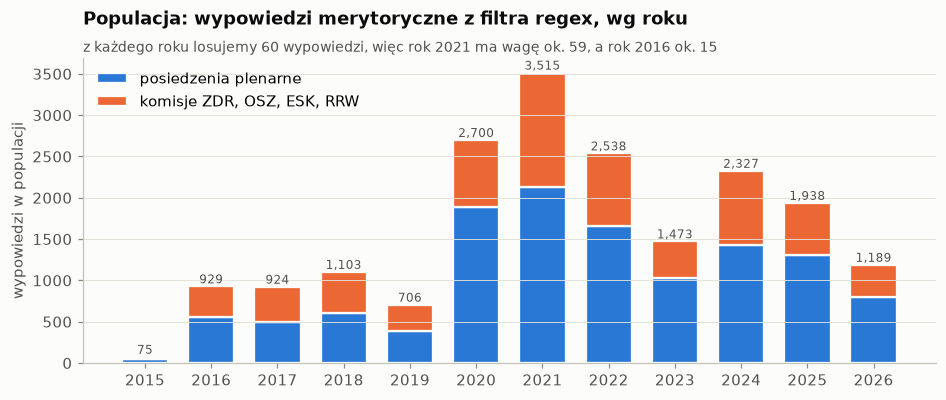

,N (populacja),n (próba),waga,% komisji: populacja,% komisji: próba
rok,,,,,
2015,75,60,1.2,42.7,43.3
2016,929,60,15.5,39.5,41.7
2017,924,60,15.4,45.7,51.7
2018,1103,60,18.4,45.1,43.3
2019,706,60,11.8,45.6,43.3
2020,2700,60,45.0,29.9,25.0
2021,3515,60,58.6,39.3,41.7
2022,2538,60,42.3,34.9,41.7
2023,1473,60,24.6,30.2,33.3


In [3]:
design = pd.DataFrame({"N (populacja)": filt.groupby("rok").size(), "n (próba)": df.groupby("rok").size()})
design["waga"] = design["N (populacja)"] / design["n (próba)"]
assert np.allclose(design["waga"], df.groupby("rok")["waga"].first())
design["% komisji: populacja"] = filt["zrodlo"].eq("komisje").groupby(filt["rok"]).mean() * 100
design["% komisji: próba"] = df["zrodlo"].eq("komisje").groupby(df["rok"]).mean() * 100

fig, ax = plt.subplots(figsize=(10, 3.6))
years = design.index
pl = filt[filt["zrodlo"] == "plenarne"].groupby("rok").size().reindex(years, fill_value=0)
ko = filt[filt["zrodlo"] == "komisje"].groupby("rok").size().reindex(years, fill_value=0)
ax.bar(years, pl, color=ACCENT, width=0.7, edgecolor=SURF, linewidth=1.5, label="posiedzenia plenarne")
ax.bar(years, ko, bottom=pl, color=SECOND, width=0.7, edgecolor=SURF, linewidth=1.5, label="komisje ZDR, OSZ, ESK, RRW")
for x, tot in zip(years, pl + ko):
    ax.text(x, tot, f"{tot:,}", ha="center", va="bottom", fontsize=8, color=INK2)
ax.set_xticks(years); ax.grid(axis="x", visible=False)
ax.set_ylabel("wypowiedzi w populacji")
ax.legend(loc="upper left")
ax.set_title("Populacja: wypowiedzi merytoryczne z filtra regex, wg roku")
subtitle(ax, "z każdego roku losujemy 60 wypowiedzi, więc rok 2021 ma wagę ok. 59, a rok 2016 ok. 15")
save(fig, "llm_a_01_populacja"); plt.show()
design.round(1)

Populacja jest nierówna w czasie: w latach 2020–2022 filtr przepuszcza 2,5–3,5 tys. wypowiedzi rocznie, w 2016–2019 0,7–1,1 tys.
(COVID podnosi liczbę trafień słowników). Przy stałym n = 60 wagi różnią się więc prawie czterokrotnie. Udział komisji w populacji
waha się między 30% a 46%; w próbie między 25% a 52%, bo losowanie nie było warstwowane po źródle.

## 1. Przegląd próby

Kto jest w próbie (miejsce wypowiedzi i rola mówcy) w porównywanych okresach. Rola: **poseł**, **rząd** (ministrowie, wiceministrowie),
**inni** (eksperci, przedstawiciele instytucji i organizacji, goście komisji).

In [4]:
comp = pd.concat({
    "miejsce": pd.crosstab(df["gremium"].map(GREMIA), df["okres"])[PERIODS],
    "rola": pd.crosstab(df["rola"], df["okres"])[PERIODS],
}).rename(columns=PERIOD_LABEL)
comp["razem"] = comp.sum(axis=1)
comp

okres                     przed COVID  COVID  po ChatGPT  razem
miejsce ESK (energia)               9     11          16     36
        OSZ (środowisko)           57      7          17     81
        RRW (rolnictwo)            51      7          14     72
        ZDR (zdrowie)              18     38          30     86
        plenarne                  170    107         168    445
rola    inni                       63     12          26    101
        poseł                     191    138         188    517
        rząd                       51     20          31    102

Skład próby różni się między okresami: przed COVID 44% wypowiedzi pochodzi z komisji (głównie OSZ i RRW), w okresie COVID 37%
(głównie ZDR), po ChatGPT 31%. Rola „inni” to 21% próby przed COVID i tylko 7% w okresie COVID. Ma to znaczenie, bo komisje
i eksperci częściej formułują twierdzenia naukowe (sekcja 6).

In [5]:
def run_summary(d):
    return pd.Series({
        "kontekst [tokeny]": ", ".join(map(str, sorted(d["num_ctx"].unique()))),
        "limit kandydatów": ", ".join(map(str, sorted(d["max_kandydatow"].unique()))),
        "prompt kroku 2": ", ".join(sorted(d["prompt_weryfikacji"].unique())),
        "błędy zgłoszone przez skrypt": int(d["blad"].notna().sum()),
        "ucięte do 2500 słów": int(d["obciete"].sum()),
        "obcięte wejście (sekcja 9.1)": int(d["przepelnienie"].sum()),
        "przesunięcie kontekstu (sekcja 9.1)": int(d["przesuniecie"].sum()),
        "pełny limit kandydatów": int((d["n_kandydatow"] >= d["max_kandydatow"]).sum()),
        "kandydaci": int(d["n_kandydatow"].sum()),
        "wypowiedzi z twierdzeniem": int(d["y"].sum()),
        "twierdzenia": int(d["n_twierdzen"].sum()),
    })

print(f"model: {df['model'].iloc[0]}, prompt kroku 1: {df['prompt'].iloc[0]}")
print(f"pierwszy przebieg: {first['sekundy'].sum() / 3600:.1f} h, średnio {first['sekundy'].mean():.0f} s / wypowiedź; "
      f"naprawa: ponowny przebieg {len(rerun_ids)} wypowiedzi {df.loc[df['wypowiedz_id'].isin(rerun_ids), 'sekundy'].sum() / 3600:.1f} h, "
      f"krok 2 dla pozostałych {df['sekundy_weryfikacji'].sum() / 3600:.1f} h")
pd.DataFrame({"pierwszy przebieg": run_summary(first), "po naprawie": run_summary(df)})

model: SpeakLeash/bielik-11b-v3.0-instruct:Q4_K_M, prompt kroku 1: etap_a_v2
pierwszy przebieg: 4.6 h, średnio 23 s / wypowiedź; naprawa: ponowny przebieg 119 wypowiedzi 1.6 h, krok 2 dla pozostałych 0.4 h


,pierwszy przebieg,po naprawie
kontekst [tokeny],8192,"8192, 16384"
limit kandydatów,8,"8, 16"
prompt kroku 2,weryfikacja_v0,weryfikacja_v1
błędy zgłoszone przez skrypt,0,0
ucięte do 2500 słów,15,15
obcięte wejście (sekcja 9.1),66,0
przesunięcie kontekstu (sekcja 9.1),26,0
pełny limit kandydatów,67,4
kandydaci,2062,2107
wypowiedzi z twierdzeniem,163,204


Pierwszy przebieg trwał 4,6 h i nie zgłosił żadnego błędu, a mimo to 92 wypowiedzi przepełniły kontekst (sekcja 9.1).
Naprawa zajęła 2 h. Po niej nie ma przepełnień, limit 16 zapełniają tylko 4 wypowiedzi, a liczba wypowiedzi z twierdzeniem
wzrosła ze 163 do 204, liczba twierdzeń z 315 do 441.

### Długość wypowiedzi

Rozkład długości w próbie i odsetek wypowiedzi z twierdzeniem w przedziałach długości (bez wag).

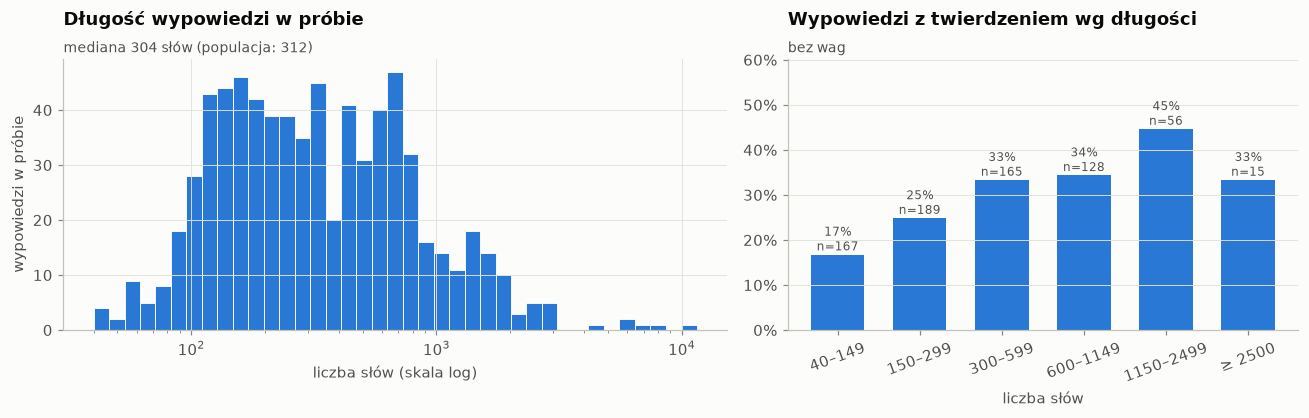

,wypowiedzi,z_twierdzeniem,twierdzenia_na_wyp,kandydaci_na_wyp,pelny_limit
dlugosc,,,,,
40–149,167,0.17,0.23,1.38,0.00
150–299,189,0.25,0.43,2.17,0.00
300–599,165,0.33,0.76,3.35,0.00
600–1149,128,0.34,0.77,3.79,0.00
1150–2499,56,0.45,1.21,6.21,0.05
≥ 2500,15,0.33,1.93,5.40,0.07


In [6]:
LEN_BINS = [40, 150, 300, 600, 1150, 2500, np.inf]
LEN_LABELS = ["40–149", "150–299", "300–599", "600–1149", "1150–2499", "≥ 2500"]
df["dlugosc"] = pd.cut(df["liczba_slow"], LEN_BINS, labels=LEN_LABELS, right=False)
df["pelny_limit"] = df["n_kandydatow"] >= df["max_kandydatow"]
by_len = df.groupby("dlugosc", observed=True).agg(
    wypowiedzi=("y", "size"), z_twierdzeniem=("y", "mean"), twierdzenia_na_wyp=("n_twierdzen", "mean"),
    kandydaci_na_wyp=("n_kandydatow", "mean"),
    pelny_limit=("pelny_limit", "mean"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.3, 1]})
bins = np.logspace(np.log10(40), np.log10(df["liczba_slow"].max() + 1), 40)
a1.hist(df["liczba_slow"], bins=bins, color=ACCENT, edgecolor=SURF, linewidth=0.6)
a1.set_xscale("log")
a1.set_xlabel("liczba słów (skala log)"); a1.set_ylabel("wypowiedzi w próbie")
a1.set_title("Długość wypowiedzi w próbie")
subtitle(a1, f"mediana {df['liczba_slow'].median():.0f} słów (populacja: {filt['liczba_slow'].median():.0f})")
x = np.arange(len(by_len))
a2.bar(x, by_len["z_twierdzeniem"], color=ACCENT, width=0.65)
for xi, (p, n) in enumerate(zip(by_len["z_twierdzeniem"], by_len["wypowiedzi"])):
    a2.text(xi, p, f"{p:.0%}\nn={n}", ha="center", va="bottom", fontsize=8, color=INK2)
a2.set_xticks(x, by_len.index, rotation=20); a2.yaxis.set_major_formatter(PCT); a2.grid(axis="x", visible=False)
a2.set_ylim(0, by_len["z_twierdzeniem"].max() * 1.35); a2.set_xlabel("liczba słów")
a2.set_title("Wypowiedzi z twierdzeniem wg długości")
subtitle(a2, "bez wag")
fig.tight_layout()
save(fig, "llm_a_02_dlugosc"); plt.show()
by_len.round(2)

Mediana długości w próbie (304 słowa) jest bliska populacji (312). Odsetek wypowiedzi z twierdzeniem rośnie z długością,
od 17% przy wypowiedziach poniżej 150 słów do 45% przy 1150–2499 słowach: dłuższa wypowiedź daje więcej okazji do twierdzenia.
W pierwszym przebiegu najdłuższe wypowiedzi miały tylko 5% i 0% z powodu przepełnienia kontekstu (sekcja 9.1).

## 2. Lejek detekcji: od kandydatów do twierdzeń

Krok 1 zwraca do 8 zdań-kandydatów z rodzajem zdania. Tylko kandydaci „naukowe” trafiają do kroku 2, który ocenia samą parafrazę,
bez kontekstu wypowiedzi.

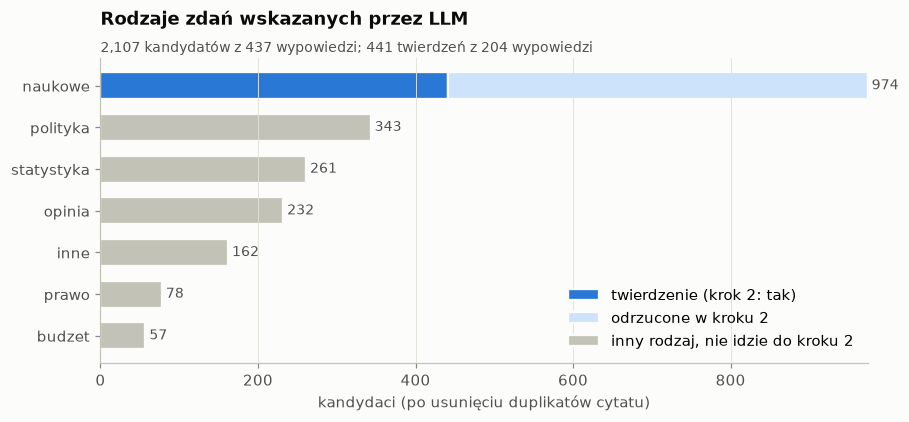

col_0,potwierdzone,odrzucone,niesprawdzane,razem
rodzaj,,,,
naukowe,441,533,0,974
polityka,0,0,343,343
statystyka,0,0,261,261
opinia,0,0,232,232
inne,0,0,162,162
prawo,0,0,78,78
budzet,0,0,57,57


In [7]:
status = np.select([cand["weryfikacja"].eq(True), cand["weryfikacja"].eq(False)], ["potwierdzone", "odrzucone"], "niesprawdzane")
kinds = pd.crosstab(cand["rodzaj"], status).reindex(columns=["potwierdzone", "odrzucone", "niesprawdzane"], fill_value=0)
kinds = kinds.loc[kinds.sum(axis=1).sort_values().index]
STATUS = {"potwierdzone": (ACCENT, "twierdzenie (krok 2: tak)"), "odrzucone": (ACCENT_LIGHT, "odrzucone w kroku 2"),
          "niesprawdzane": (AXIS, "inny rodzaj, nie idzie do kroku 2")}

fig, ax = plt.subplots(figsize=(9, 3.6))
left = np.zeros(len(kinds))
for s in kinds.columns:
    ax.barh(range(len(kinds)), kinds[s], left=left, color=STATUS[s][0], height=0.65, edgecolor=SURF, linewidth=1.5, label=STATUS[s][1])
    left += kinds[s].values
for i, tot in enumerate(left):
    ax.text(tot, i, f" {int(tot)}", va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(kinds)), kinds.index); ax.grid(axis="y", visible=False)
ax.set_xlabel("kandydaci (po usunięciu duplikatów cytatu)")
ax.legend(loc="lower right")
ax.set_title("Rodzaje zdań wskazanych przez LLM")
subtitle(ax, f"{len(cand):,} kandydatów z {int(df['n_kandydatow'].gt(0).sum())} wypowiedzi; "
             f"{kinds['potwierdzone'].sum()} twierdzeń z {int(df['y'].sum())} wypowiedzi")
save(fig, "llm_a_03_rodzaje"); plt.show()
kinds.loc[::-1].assign(razem=kinds.sum(axis=1))

Z 2107 kandydatów 46% to zdania „naukowe”, a krok 2 potwierdza 45% z nich (441 twierdzeń w 204 wypowiedziach). Najczęstsze inne
rodzaje to polityka i statystyka. Wysoki odsetek odrzuceń w kroku 2 może znaczyć, że krok 1 zbyt łatwo nadaje rodzaj „naukowe”
(i krok 2 słusznie odsiewa), albo że krok 2 gubi prawdziwe twierdzenia. Rozstrzygnęłaby to dopiero ręczna anotacja (sekcja 9.4).

## 3. Agregacja po wypowiedzi

LLM pracuje na twierdzeniach, a hipotezy mówią o wypowiedziach, więc potrzebne są obie jednostki:

* **wypowiedź z twierdzeniem**: wypowiedź z co najmniej jednym potwierdzonym twierdzeniem (0/1);
* **twierdzenia na 100 wypowiedzi**: średnia liczba twierdzeń na wypowiedź × 100;
* **szacunki dla populacji**: suma wag (estymator Horvitza–Thompsona), czyli ile takich wypowiedzi i twierdzeń jest w całej populacji filtra.

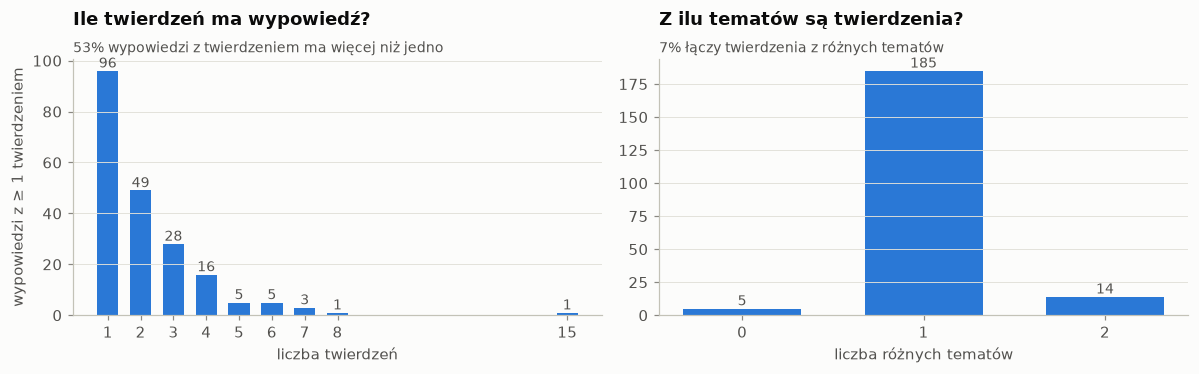

wypowiedzi z twierdzeniem: 204; z > 1 twierdzeniem: 53%; z twierdzeniami z > 1 tematu: 7%


In [8]:
z = df[df["y"] == 1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, title, xl in [(a1, "n_twierdzen", "Ile twierdzeń ma wypowiedź?", "liczba twierdzeń"),
                           (a2, "n_tematow", "Z ilu tematów są twierdzenia?", "liczba różnych tematów")]:
    vc = z[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=ACCENT, width=0.65)
    for k, v in vc.items():
        ax.text(k, v, f"{v}", ha="center", va="bottom", fontsize=9, color=INK2)
    ax.set_xticks(vc.index); ax.grid(axis="x", visible=False); ax.set_xlabel(xl)
    ax.set_title(title)
a1.set_ylabel("wypowiedzi z ≥ 1 twierdzeniem")
subtitle(a1, f"{(z['n_twierdzen'] > 1).mean():.0%} wypowiedzi z twierdzeniem ma więcej niż jedno")
subtitle(a2, f"{(z['n_tematow'] > 1).mean():.0%} łączy twierdzenia z różnych tematów")
fig.tight_layout()
save(fig, "llm_a_04_jednostka"); plt.show()
print(f"wypowiedzi z twierdzeniem: {len(z)}; z > 1 twierdzeniem: {(z['n_twierdzen'] > 1).mean():.0%}; "
      f"z twierdzeniami z > 1 tematu: {(z['n_tematow'] > 1).mean():.0%}")

In [9]:
b_y = R.bootstrap(df, "okres").loc[PERIODS]
b_n = R.bootstrap(df, "okres", y="n_twierdzen").loc[PERIODS]
ones = df.assign(one=1)
units = pd.DataFrame({
    "n (próba)": b_y["n"],
    "wypowiedzi z twierdzeniem [%]": fmt_ci(b_y),
    "twierdzenia na 100 wypowiedzi": fmt_ci(b_n),
    "twierdzenia na wypowiedź z twierdzeniem": R.weighted_share(z, "okres", y="n_twierdzen").loc[PERIODS].round(2),
    "szac. wypowiedzi w populacji": R.weighted_total(ones, "okres", y="one").loc[PERIODS].round().astype(int),
    "szac. wypowiedzi z twierdzeniem": R.weighted_total(df, "okres").loc[PERIODS].round().astype(int),
    "szac. twierdzenia": R.weighted_total(df, "okres", y="n_twierdzen").loc[PERIODS].round().astype(int),
}).rename(index=PERIOD_LABEL)
units.loc["razem"] = ["", "", "", "", *units.iloc[:, 4:].sum()]
units

,n (próba),wypowiedzi z twierdzeniem [%],twierdzenia na 100 wypowiedzi,twierdzenia na wypowiedź z twierdzeniem,szac. wypowiedzi w populacji,szac. wypowiedzi z twierdzeniem,szac. twierdzenia
okres,,,,,,,
przed COVID,305,36.1 [30.0; 41.9],85.1 [68.1; 104.1],2.36,3962,1430,3370
COVID,170,23.6 [17.2; 30.4],48.8 [31.8; 67.4],2.07,8316,1966,4062
po ChatGPT,245,21.1 [16.1; 26.5],38.1 [27.4; 50.3],1.81,7138,1506,2719
razem,,,,,19416,4902,10151


Przykład wypowiedzi z twierdzeniami z kilku tematów (najwięcej tematów w próbie):

In [10]:
ex_id = df.sort_values(["n_tematow", "n_twierdzen"], ascending=False)["wypowiedz_id"].iloc[0]
r = df.set_index("wypowiedz_id").loc[ex_id]
print(f"{ex_id}: {r['data']:%Y-%m-%d}, {GREMIA[r['gremium']]}, {r['rola']}, {r['liczba_slow']} słów")
cl.loc[cl["wypowiedz_id"] == ex_id, ["temat", "atrybucja", "twierdzenie"]]

9_81_2023-08-17_266: 2023-08-17, plenarne, poseł, 330 słów


,temat,atrybucja,twierdzenie
361,klimat,wlasne,Zmiany klimatu przyczyniają się do wzrostu liczby zachorowań na choroby odkleszczowe w Polsce.
362,klimat,wlasne,Ocieplenie klimatu sprzyja aktywności i rozprzestrzenianiu się kleszczy w Polsce.
363,klimat,wlasne,"Kleszczowe zapalenie mózgu to poważna, potencjalnie śmiertelna choroba."
364,klimat,wlasne,Nie istnieje skuteczne lekarstwo na wirusa wywołującego kleszczowe zapalenie mózgu.
365,szczepienia,wlasne,Szczepionka przeciw kleszczowemu zapaleniu mózgu ma skuteczność powyżej 95%.


**Wnioski z agregacji.**

* Ponad połowa (53%) wypowiedzi z twierdzeniem ma ich więcej niż jedno, zwykle z jednego tematu; 7% łączy różne tematy
  (powyżej: ocieplenie klimatu sprzyja kleszczom, a szczepionka chroni przed kleszczowym zapaleniem mózgu). Kilka twierdzeń w wypowiedzi może mieć różny status (jedno
  prawdziwe, drugie fałszywe), więc ocena „cała wypowiedź sprzeczna / niesprzeczna” by je mieszała. Dlatego jednostką etapu B
  jest twierdzenie, a wynik wypowiedzi to agregat.
* Obie miary wskazują ten sam kierunek: przed COVID 36% wypowiedzi z twierdzeniem i 85 twierdzeń na 100 wypowiedzi,
  w kolejnych okresach 21–24% i 38–49.
* Liczby bezwzględne pokazują coś odwrotnego: szacowana liczba twierdzeń w populacji jest najwyższa w okresie COVID
  (ok. 4,1 tys. wobec 3,4 tys. przed COVID), bo populacja filtra jest ponad dwa razy większa. Okresy mają przy tym różną długość
  (ok. 4,2 / 2,8 / 3,8 roku). Wybór miary i mianownika może więc zmienić wniosek (sekcja 10.3).

## 4. Tematy

### 4.1 Ile materiału daje każdy temat: słownik a LLM

Dla każdego tematu w próbie: ile wypowiedzi ma trafienie słownika (jak w `01`), a ile zawiera twierdzenie naukowe z tego tematu wg LLM.
Zbiory nie są zagnieżdżone: LLM może przypisać temat wypowiedzi bez trafienia słownika.

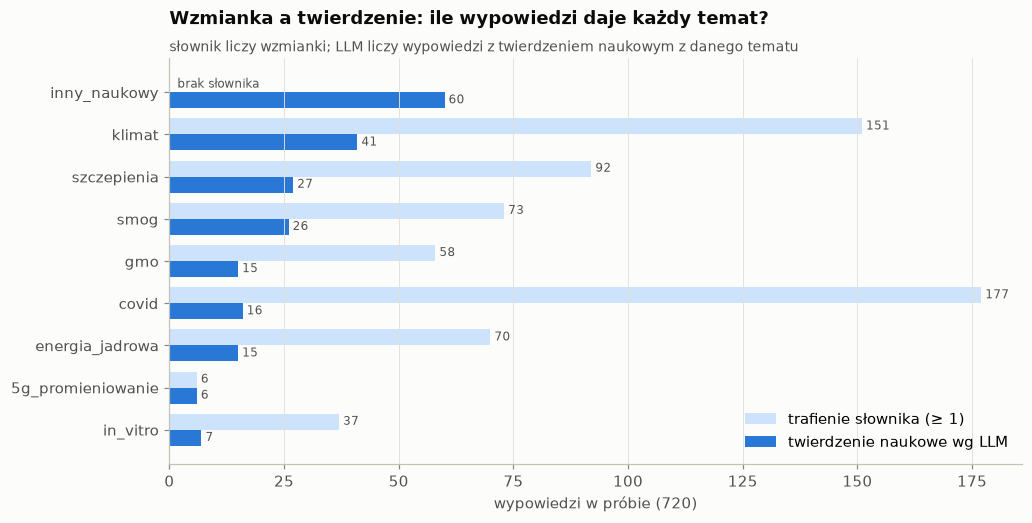

,twierdzenia,wypowiedzi: LLM,wypowiedzi: regex ≥ 1,wypowiedzi: regex ≥ 3,LLM wśród regex ≥ 1 [%],regex ≥ 1 wśród LLM [%]
inny_naukowy,157,60,NaN,NaN,NaN,NaN
klimat,74,41,151.0,33.0,19.9,73.2
szczepienia,53,27,92.0,41.0,26.1,88.9
smog,37,26,73.0,15.0,28.8,80.8
gmo,29,15,58.0,22.0,25.9,100.0
covid,28,16,177.0,45.0,7.9,87.5
energia_jadrowa,26,15,70.0,14.0,14.3,66.7
5g_promieniowanie,15,6,6.0,4.0,100.0,100.0
in_vitro,13,7,37.0,10.0,18.9,100.0


In [11]:
rows = []
for t in TOPICS_LLM:
    llm_t = df[f"tw_{t}"].eq(1)
    row = {"twierdzenia": int(cl["temat"].eq(t).sum()), "wypowiedzi: LLM": int(llm_t.sum())}
    if t in TOPICS:
        rx = df[t].gt(0)
        row |= {"wypowiedzi: regex ≥ 1": int(rx.sum()), "wypowiedzi: regex ≥ 3": int(df[t].ge(T.PROG).sum()),
                "LLM wśród regex ≥ 1 [%]": 100 * llm_t[rx].mean(),
                "regex ≥ 1 wśród LLM [%]": 100 * rx[llm_t].mean() if llm_t.any() else np.nan}
    rows.append(row)
topics_tab = pd.DataFrame(rows, index=TOPICS_LLM).sort_values("twierdzenia", ascending=False)

order = topics_tab.index[::-1]
yy = np.arange(len(order)); h = 0.38
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(yy + h / 2, topics_tab.loc[order, "wypowiedzi: regex ≥ 1"].fillna(0), height=h, color=ACCENT_LIGHT, label="trafienie słownika (≥ 1)")
ax.barh(yy - h / 2, topics_tab.loc[order, "wypowiedzi: LLM"], height=h, color=ACCENT, label="twierdzenie naukowe wg LLM")
for yi, t in enumerate(order):
    a, b = topics_tab.at[t, "wypowiedzi: regex ≥ 1"], topics_tab.at[t, "wypowiedzi: LLM"]
    ax.text(0 if np.isnan(a) else a, yi + h / 2, "  brak słownika" if np.isnan(a) else f" {a:.0f}", va="center", fontsize=8, color=INK2)
    ax.text(b, yi - h / 2, f" {b}", va="center", fontsize=8, color=INK2)
ax.set_yticks(yy, order); ax.grid(axis="y", visible=False)
ax.set_xlabel("wypowiedzi w próbie (720)")
ax.legend(loc="lower right")
ax.set_title("Wzmianka a twierdzenie: ile wypowiedzi daje każdy temat?")
subtitle(ax, "słownik liczy wzmianki; LLM liczy wypowiedzi z twierdzeniem naukowym z danego tematu")
save(fig, "llm_a_05_tematy_skala"); plt.show()
topics_tab.round(1)

* **Ponad jedna trzecia twierdzeń jest spoza słowników.** Najwięcej twierdzeń (157 z 441) LLM przypisał do `inny_naukowy`:
  zdrowie publiczne, onkologia, weterynaria, ochrona roślin, energetyka. Słowniki nie były ustawione na ten materiał.
* **Wzmianka rzadko oznacza twierdzenie.** Wśród wypowiedzi ze słowem ze słownika COVID tylko 8% (14 ze 177) zawiera twierdzenie
  naukowe o COVID; dla klimatu 20%, szczepień 26%, smogu 29%. COVID w Sejmie to głównie organizacja ochrony zdrowia, obostrzenia
  i finansowanie, a nie twierdzenia o wirusie. Skala tematów z `01`, gdzie COVID jest największym tematem, przecenia więc materiał
  dla etapu B.
* W drugą stronę słowniki działają dobrze: 73–100% wypowiedzi z twierdzeniem z danego tematu ma trafienie słownika tego tematu.
  Wyjątek to `energia_jadrowa` (67%), bo LLM używa tej etykiety szerzej (4.4).

### 4.2 Tematy w okresach

Wypowiedzi z twierdzeniem z danego tematu **na 1000 wypowiedzi populacji** (estymator ważony), analogicznie do heatmapy kadencji w `01`.
Pod wykresem liczby twierdzeń w próbie: małe liczności oznaczają dużą niepewność.

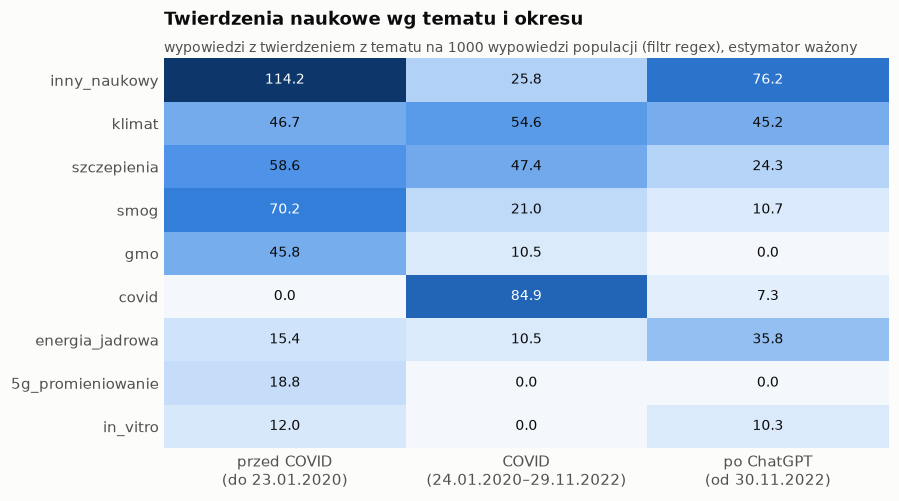

okres,przed COVID,COVID,po ChatGPT,razem
inny_naukowy,111,7,39,157
klimat,38,20,16,74
szczepienia,29,15,9,53
smog,26,5,6,37
gmo,25,4,0,29
covid,0,26,2,28
energia_jadrowa,6,2,18,26
5g_promieniowanie,15,0,0,15
in_vitro,9,0,4,13


In [12]:
heat = pd.DataFrame({t: R.weighted_share(df, "okres", y=f"tw_{t}") * 1000 for t in TOPICS_LLM}).T[PERIODS].loc[topics_tab.index]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.imshow(heat.values, cmap=SEQ, aspect="auto", vmin=0)
ax.set_xticks(range(len(PERIODS)), [PERIOD_TICK[p] for p in PERIODS]); ax.set_yticks(range(len(heat)), heat.index)
ax.grid(False); ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
thr = heat.values.max() * 0.55
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9, color="white" if v > thr else INK)
ax.set_title("Twierdzenia naukowe wg tematu i okresu")
subtitle(ax, "wypowiedzi z twierdzeniem z tematu na 1000 wypowiedzi populacji (filtr regex), estymator ważony")
save(fig, "llm_a_06_tematy_okresy"); plt.show()
counts = pd.crosstab(cl["temat"], cl["okres"]).reindex(index=heat.index, columns=PERIODS, fill_value=0).rename(columns=PERIOD_LABEL)
counts.assign(razem=counts.sum(axis=1))

COVID występuje praktycznie tylko w okresie COVID, klimat we wszystkich okresach, GMO i 5G głównie przed COVID, a „energia
jądrowa” rośnie po ChatGPT (ale to głównie CCS i OZE, zob. 4.4). Komórki opierają się na 0–111 twierdzeniach, więc różnice między
okresami dla pojedynczych tematów są orientacyjne.

### 4.3 Przykładowe twierdzenia (kontrola jakości)

Losowo po dwa twierdzenia z każdego tematu: cytat z wypowiedzi i parafraza LLM. Odpowiednik przeglądu trafień słowników w `01`.

In [13]:
def who(r):
    return r["blok"] if r["rola"] == "poseł" and isinstance(r["blok"], str) else r["rola"]

lines = []
for t in topics_tab.index:
    s = cl[cl["temat"] == t]
    lines.append(f"**{t}**")
    for _, r in s.sample(min(2, len(s)), random_state=3).iterrows():
        lines.append(f"- *{r['data']:%Y-%m-%d}, {GREMIA[r['gremium']]}, {who(r)}:* „{r['cytat']}” → {r['twierdzenie']}")
display(Markdown("\n".join(lines)))

**inny_naukowy**
- *2017-10-26, RRW (rolnictwo), inni:* „Efektem podstawowym takiego wapnowania jest zwiększona przyswajalność nawozów przez glebę, a przez to mniejsze odprowadzenie nawozów do wód gruntowych, a w związku z tym mniejsza strata azotu i fosforu do wód gruntowych, a następnie do Bałtyku.” → Wapnowanie zmniejsza straty azotu i fosforu, ograniczając ich przedostawanie się do wód gruntowych i Bałtyku.
- *2015-12-10, RRW (rolnictwo), rząd:* „Gospodarstwo musi mieć opracowany program monitorowania i zwalczania gryzoni, dokonywać okresowo zabiegów dezynsekcji, rejestrować środki transportu i osoby mające kontakt ze świniami.” → Wymagania bioasekuracji obejmują m.in. monitorowanie gryzoni, dezynsekcję, rejestrację transportu i osób mających kontakt ze świniami.
**klimat**
- *2015-12-29, OSZ (środowisko), PiS:* „Czy ten temat był poruszany? Oczywiście mówię o tym „buraku cukrowym” w takiej przenośni, ale on występował dokładnie jako burak cukrowy.” → Plantacje rolne, takie jak burak cukrowy, mogą mieć znaczący wpływ na redukcję dwutlenku węgla, podobnie jak lasy.
- *2016-01-14, plenarne, rząd:* „To była sprawa związana z rolą lasów i pochłaniania dwutlenku węgla przez żywe zasoby przyrodnicze jako sposobu na walkę ze zmianami klimatu i z ograniczeniem emisji dwutlenku węgla.” → Lasy i żywe zasoby przyrodnicze pochłaniają dwutlenek węgla, co pomaga w walce ze zmianami klimatu.
**szczepienia**
- *2018-10-03, plenarne, inni:* „Trudno jest obecnie przewidzieć, jakie dla stanu uodpornienia populacji będą skutki zniesienia obowiązku szczepień ochronnych przewidzianego w projekcie ustawy. Należy mieć na uwadze, że po zniesieniu obowiązku szczepień ochronnych kolejne roczniki dzieci i młodzieży będą zaszczepione jedynie w odse” → Zniesienie obowiązku szczepień może prowadzić do spadku odsetka zaszczepionych dzieci i młodzieży do około 70%, co stworzy warunki do epidemicznego szerzenia się chorób zakaźnych.
- *2023-06-14, plenarne, KO:* „Przerażające jest bowiem, że na całym świecie średnio co 6 sekund przedwcześnie umiera jedna osoba z powodu palenia papierosów i narażania na oddziaływanie toksycznych substancji dymu nikotynowego, zaś w Polsce palenie tytoniu jest jednym z głównych czynników ryzyka przewlekłych chorób niezakaźnych.” → Palenie tytoniu jest jednym z głównych czynników ryzyka przewlekłych chorób niezakaźnych i powoduje przedwczesne zgony.
**smog**
- *2017-01-26, plenarne, rząd:* „w zakresie jakości powietrza, jeżeli chodzi o te wielkie instalacje, przemysłowe, ustanowiono pewnego rodzaju rekord świata, dlatego że dokonaliśmy redukcji do roku, o ile mnie pamięć nie myli, 2004 na poziomie pięćdziesięciu paru procent, a w tej chwili na poziomie 80%” → Dokonano znaczącej redukcji zanieczyszczeń powietrza z wielkich instalacji przemysłowych w Polsce, osiągając poziom 80% redukcji w porównaniu do 2004 roku.
- *2020-02-12, plenarne, KO:* „Już dziś każdego roku umiera 45 tys. Polaków z powodu smogu.” → Smog powoduje rocznie 45 tys. zgonów w Polsce.
**gmo**
- *2018-02-06, OSZ (środowisko), inni:* „wydaje się że cała procedura wydawania pozwolenia dopuszczania GMO do uprawy i decyzja warunków prowadzenia uprawy ze strony organu gwarantują, że podmiot, który będzie ją prowadził zgodnie z nimi, nie będzie powodował tych szkód, które tu zostały wymienione.” → Procedura wydawania pozwolenia na uprawę GMO i warunki prowadzenia uprawy gwarantują, że podmiot przestrzegający tych warunków nie spowoduje szkód.
- *2018-01-10, OSZ (środowisko), rząd:* „Będzie to weryfikowane przez potężne grono naukowców, przyrodników, genetyków itd.” → Weryfikacja wniosków dotyczących GMO odbywa się przez zespół ekspertów naukowych.
**covid**
- *2021-04-15, plenarne, KO:* „Szczepienia, testy i tlen są głównymi narzędziami w walce z COVID-19.” → Szczepienia, testy i tlen ograniczają liczbę zgonów z powodu COVID-19.
- *2021-04-15, plenarne, KO:* „COVID zabija na całym świecie.” → COVID-19 powoduje zgony na całym świecie.
**energia_jadrowa**
- *2024-01-24, OSZ (środowisko), inni:* „Jesteśmy przekonani, że w całym cyklu życia reaktora, czyli 60 latach, ta emisyjność pozwali na oszczędzenie 175 mln ton CO2.” → Reaktor jądrowy BWRX-300 pozwoli zaoszczędzić 175 mln ton CO2 w ciągu 60 lat eksploatacji.
- *2024-01-24, OSZ (środowisko), inni:* „Emisyjność reaktorów jądrowych w pełnej skali, czyli od kołyski do końca eksploatacji, jest dzisiaj najniższa i porównywana z wiatrem, i umożliwi głęboką dekarbonizację polskiej gospodarki.” → Emisyjność reaktorów jądrowych jest najniższa w porównaniu z innymi źródłami energii i umożliwia dekarbonizację polskiej gospodarki.
**5g_promieniowanie**
- *2019-07-16, OSZ (środowisko), inni:* „To nie jest do końca prawda, że wszyscy naukowcy się zgadzają, że to nie ma skutków negatywnych” → Nie wszyscy naukowcy zgadzają się co do braku negatywnych skutków 5G, co potwierdzają międzynarodowe apele naukowców.
- *2019-07-03, plenarne, KO:* „Nie da się uruchomić sieci internetowej 5G bez dostępu do pasma 700 MHz.” → Dostęp do pasma 700 MHz jest niezbędny do uruchomienia sieci 5G.
**in_vitro**
- *2016-09-22, plenarne, KO:* „metoda in vitro jest najskuteczniejszą obecnie dostępną procedurą medyczną w leczeniu niepłodności.” → In vitro to najskuteczniejsza dostępna metoda leczenia niepłodności.
- *2016-09-22, plenarne, KO:* „dzięki metodzie in vitro na świecie w tej chwili urodziło się 6,5 mln dzieci.” → Metoda in vitro umożliwiła urodzenie 6,5 mln dzieci na świecie.

### 4.4 Temat `energia_jadrowa`

Czy twierdzenia oznaczone jako energia jądrowa dotyczą atomu (słowa kluczowe w cytacie lub parafrazie)?

In [14]:
NUC = r"jądr|atom|reaktor|uran|SMR"
ej = cl[cl["temat"] == "energia_jadrowa"]
about = ej["twierdzenie"].str.contains(NUC, case=False) | ej["cytat"].str.contains(NUC, case=False)
print(f"energia_jadrowa: {len(ej)} twierdzeń, o atomie: {about.mean():.0%}")
ej.loc[~about, ["rok", "twierdzenie"]]

energia_jadrowa: 26 twierdzeń, o atomie: 31%


,rok,twierdzenie
73,2016,"Magazyny energii dla wiatraków nie są jeszcze opłacalne, z wyjątkiem specjalistycznych rozwiązań, takich jak koszt Benninga."
207,2018,"Efektywność jednoczesnej produkcji ciepła i prądu jest o ok. 50% wyższa niż w przypadku ich oddzielnego wytwarzania, co prowadzi do ograniczenia emisji zanieczyszczeń."
212,2019,Wyniki badań zostaną wykorzystane do analiz i symulacji na potrzeby raportów środowiskowych i lokalizacyjnych.
264,2020,Efektywność OZE zależy od warunków pogodowych - sama moc zainstalowana nie gwarantuje produkcji energii.
326,2022,OZE nie są stabilnym źródłem energii.
347,2023,System CCS (carbon capture and storage) jest potrzebny dla przemysłu cementowego w celu redukcji emisji CO2.
354,2023,"Technologia podziemnego składowania dwutlenku węgla jest sprawdzona i stosowana na szeroką skalę w wielu krajach, w tym w Stanach Zjednoczonych, Kanadzie i Europie."
355,2023,"Nie wszystkie obszary w Polsce nadają się do podziemnego składowania dwutlenku węgla, co wynika z wymagań geologicznych."
356,2023,"Zatłaczanie CO2 do górotworów złoż węglowodorów zwiększa energię złożową, co pozwala na efektywniejsze pozyskiwanie ropy naftowej i gazu ziemnego."
357,2023,"Zbiorniki na dwutlenek węgla muszą spełniać określone kryteria szczelności, aby zapewnić bezpieczeństwo."


Tylko 8 z 26 twierdzeń `energia_jadrowa` dotyczy atomu. Reszta to składowanie CO2 (7 twierdzeń z jednej wypowiedzi eksperckiej
z 2023 r.), OZE, energetyka wiatrowa i kogeneracja: model traktuje etykietę jako „energetyka”. Analiza per temat musi to uwzględniać
(np. osobny temat `energetyka` albo doprecyzowanie etykiety w prompcie).

## 5. Czas

### 5.1 Udział wypowiedzi z twierdzeniem i liczba twierdzeń, wg roku

Obie miary z estymatora ważonego; 95% przedział z bootstrapu (losowanie ze zwracaniem w obrębie roku, 2000 powtórzeń).

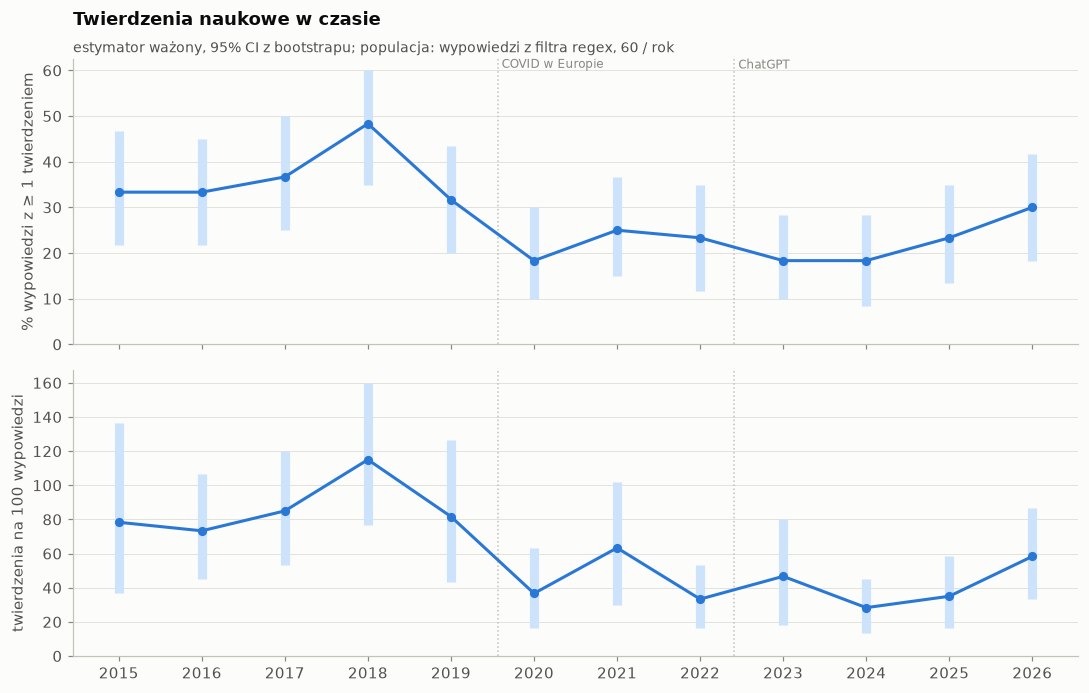

,n,z twierdzeniem [%],twierdzenia / 100 wyp.
rok,,,
2015,60,33.3 [21.7; 46.7],78.3 [36.7; 136.7]
2016,60,33.3 [21.7; 45.0],73.3 [45.0; 106.7]
2017,60,36.7 [25.0; 50.0],85.0 [53.3; 120.0]
2018,60,48.3 [35.0; 60.0],115.0 [76.7; 160.0]
2019,60,31.7 [20.0; 43.3],81.7 [43.3; 126.7]
2020,60,18.3 [10.0; 30.0],36.7 [16.7; 63.4]
2021,60,25.0 [15.0; 36.7],63.3 [30.0; 101.7]
2022,60,23.3 [11.7; 35.0],33.3 [16.7; 53.3]
2023,60,18.3 [10.0; 28.3],46.7 [18.3; 80.0]


In [15]:
yr_y = R.bootstrap(df, "rok")
yr_n = R.bootstrap(df, "rok", y="n_twierdzen")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True)
for ax, b, lab in [(a1, yr_y, "% wypowiedzi z ≥ 1 twierdzeniem"), (a2, yr_n, "twierdzenia na 100 wypowiedzi")]:
    ax.errorbar(b.index, b["p"] * 100, yerr=[(b["p"] - b["lo"]) * 100, (b["hi"] - b["p"]) * 100],
                fmt="o-", color=ACCENT, ecolor=ACCENT_LIGHT, elinewidth=6, capsize=0, ms=5)
    ax.set_ylim(0, None); ax.set_ylabel(lab); ax.grid(axis="x", visible=False)
    period_lines(ax, label=ax is a1)
a2.set_xticks(yr_y.index)
a1.set_title("Twierdzenia naukowe w czasie")
subtitle(a1, "estymator ważony, 95% CI z bootstrapu; populacja: wypowiedzi z filtra regex, 60 / rok")
fig.tight_layout()
save(fig, "llm_a_udzial_rok"); plt.show()
pd.DataFrame({"n": yr_y["n"], "z twierdzeniem [%]": fmt_ci(yr_y), "twierdzenia / 100 wyp.": fmt_ci(yr_n)}, index=yr_y.index)

Udział wypowiedzi z twierdzeniem jest najwyższy w latach 2015–2019 (32–48%, szczyt w 2018), najniższy w 2020, 2023 i 2024 (18%),
a w 2026 wraca do 30%. Przedział dla pojedynczego roku ma szerokość ok. 25 pp, więc różnice z roku na rok mieszczą się w szumie.
Stabilniejsze są porównania okresów (5.4).

### 5.2 Wolumen: ile twierdzeń jest w populacji

Udział to nie wszystko: w 2020–2022 populacja filtra jest 2–4 razy większa niż w 2016–2019 (COVID podnosi liczbę trafień słowników).
Szacowane liczby bezwzględne:

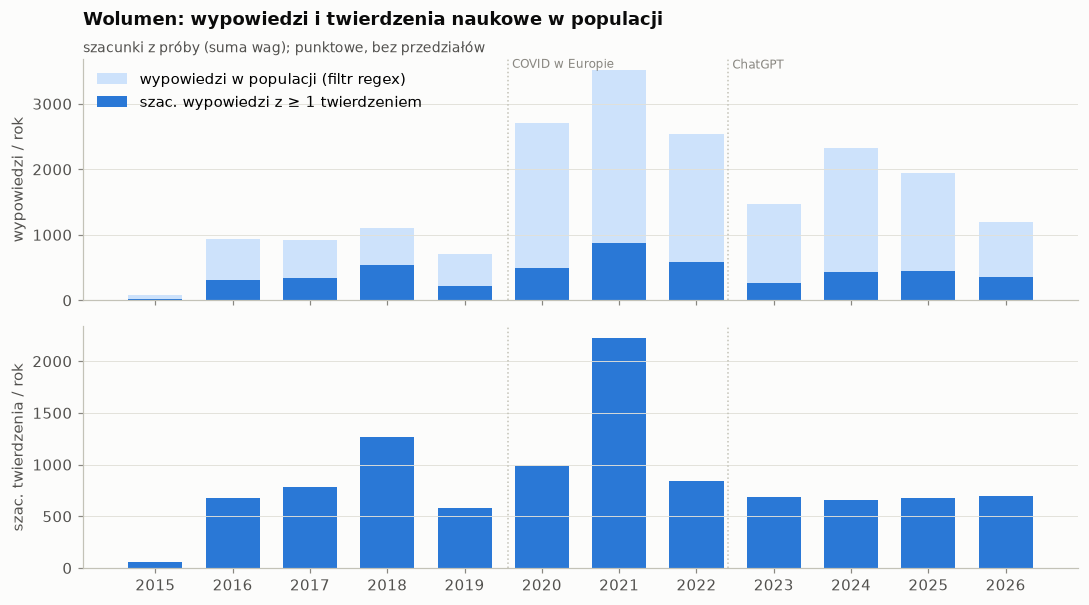

rok,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
N populacji,75,929,924,1103,706,2700,3515,2538,1473,2327,1938,1189
szac. wyp. z twierdzeniem,25,310,339,533,224,495,879,592,270,427,452,357
szac. twierdzenia,59,681,785,1268,577,990,2226,846,687,659,678,694


In [16]:
N_year = R.weighted_total(ones, "rok", y="one")
est_y = R.weighted_total(df, "rok")
est_n = R.weighted_total(df, "rok", y="n_twierdzen")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
a1.bar(N_year.index, N_year, color=ACCENT_LIGHT, width=0.7, label="wypowiedzi w populacji (filtr regex)")
a1.bar(est_y.index, est_y, color=ACCENT, width=0.7, label="szac. wypowiedzi z ≥ 1 twierdzeniem")
a1.legend(loc="upper left"); a1.set_ylabel("wypowiedzi / rok"); a1.grid(axis="x", visible=False)
period_lines(a1)
a2.bar(est_n.index, est_n, color=ACCENT, width=0.7)
a2.set_ylabel("szac. twierdzenia / rok"); a2.grid(axis="x", visible=False)
period_lines(a2, label=False)
a2.set_xticks(N_year.index)
a1.set_title("Wolumen: wypowiedzi i twierdzenia naukowe w populacji")
subtitle(a1, "szacunki z próby (suma wag); punktowe, bez przedziałów")
fig.tight_layout()
save(fig, "llm_a_07_wolumen"); plt.show()
pd.DataFrame({"N populacji": N_year.round().astype(int), "szac. wyp. z twierdzeniem": est_y.round().astype(int),
              "szac. twierdzenia": est_n.round().astype(int)}).T

W liczbach bezwzględnych obraz się odwraca: w 2021 r. szacujemy ok. 2,2 tys. twierdzeń, najwięcej w całym okresie, bo populacja
liczy 3,5 tys. wypowiedzi. Spadek udziału w latach COVID wynika więc przynajmniej częściowo z mianownika. Filtr regex przepuszcza
wtedy wiele wypowiedzi o pandemii, w których nie ma twierdzeń naukowych (4.1: tylko 8% wypowiedzi wspominających COVID
ma twierdzenie o COVID).

### 5.3 Tematy w czasie

Szacowana liczba wypowiedzi z twierdzeniem z danego tematu, wg roku (odpowiednik wykresu tematów w czasie z `01`).
W nawiasie liczba wypowiedzi w próbie, na której opiera się szacunek.

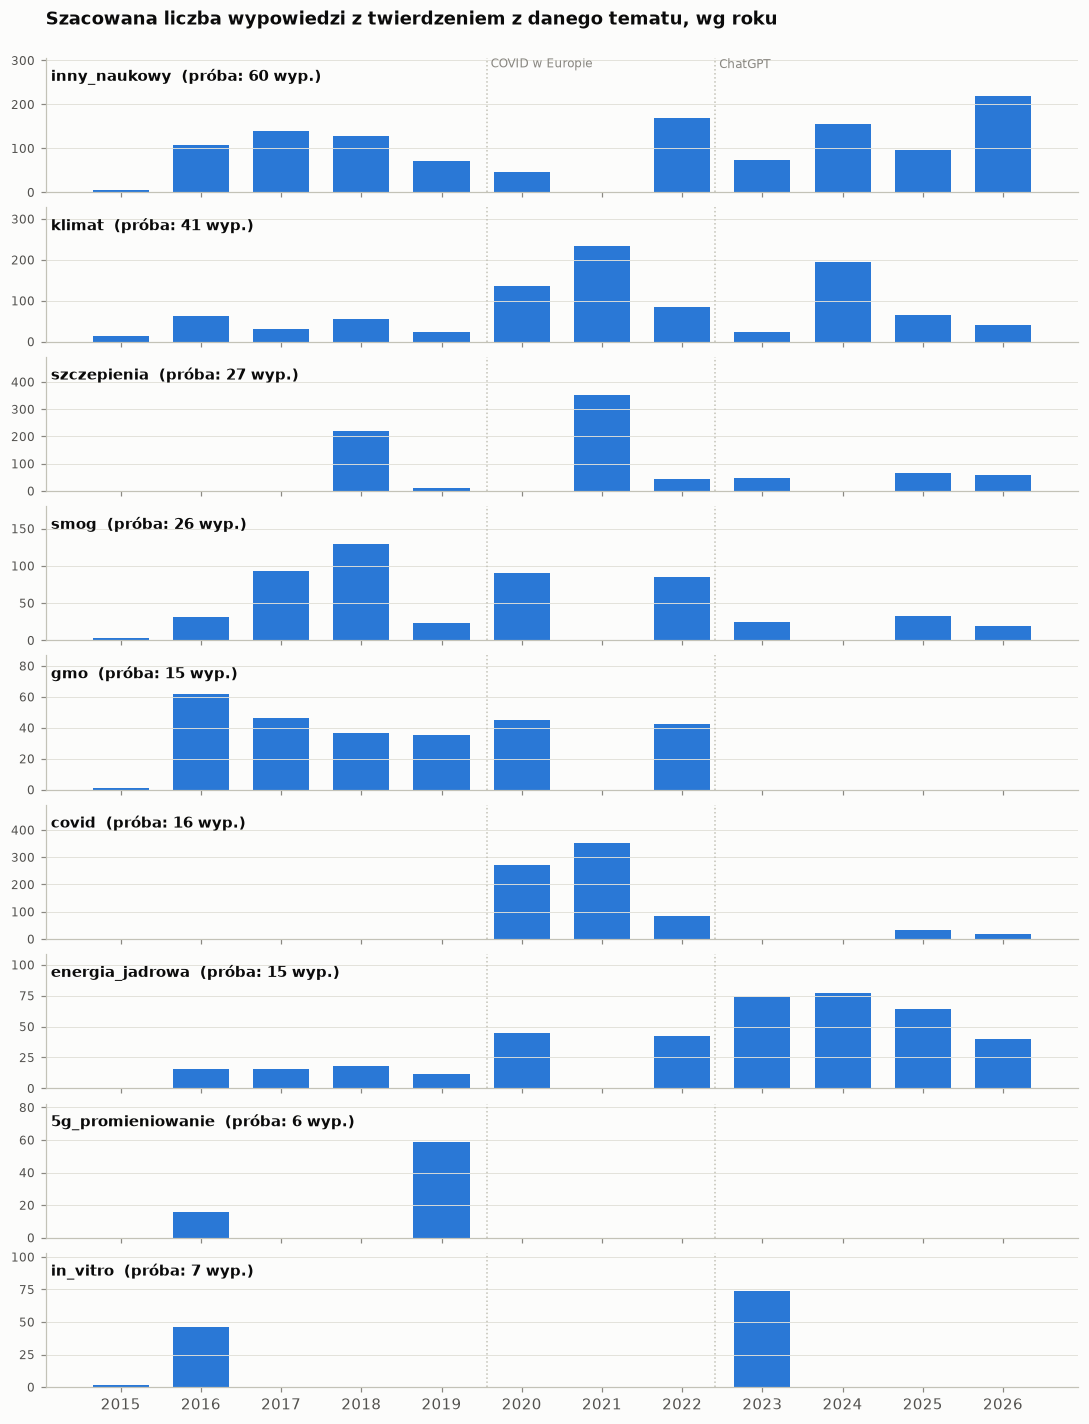

In [17]:
est_topic = pd.DataFrame({t: R.weighted_total(df, "rok", y=f"tw_{t}") for t in TOPICS_LLM})
fig, axes = plt.subplots(len(topics_tab), 1, figsize=(10, 1.45 * len(topics_tab)), sharex=True)
for ax, t in zip(axes, topics_tab.index):
    s = est_topic[t]
    ax.bar(s.index, s.values, color=ACCENT, width=0.7)
    period_lines(ax, label=ax is axes[0])
    ax.set_ylim(0, max(s.max() * 1.4, 1))
    ax.text(0.005, 0.92, f"{t}  (próba: {int(df[f'tw_{t}'].sum())} wyp.)", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=INK, va="top")
    ax.tick_params(axis="y", labelsize=8); ax.grid(axis="x", visible=False)
axes[-1].set_xticks(est_topic.index)
axes[0].set_title("Szacowana liczba wypowiedzi z twierdzeniem z danego tematu, wg roku")
fig.tight_layout(h_pad=0.4)
save(fig, "llm_a_08_tematy_w_czasie"); plt.show()

COVID widać głównie w latach 2020–2022, smog przede wszystkim w latach 2017–2018, GMO znika po 2022 r., a „energię jądrową”
najczęściej w latach 2022–2025. Szacunki dla
pojedynczego tematu i roku opierają się na 0–5 wypowiedziach z próby, więc wykres pokazuje raczej, kiedy temat w ogóle występuje,
niż jak często.

### 5.4 Porównanie okresów H1: dwie jednostki, dwa źródła

Różnice między okresami (późniejszy minus wcześniejszy) dla obu miar, osobno dla całej próby, posiedzeń plenarnych i komisji.
To jeszcze nie test H1 (mierzymy twierdzenia naukowe, nie sprzeczne z konsensusem), ale pokazuje, jak wybór jednostki
i mianownika zmienia obraz.

In [18]:
PAIRS = [("przed_covid", "covid"), ("przed_covid", "po_chatgpt"), ("covid", "po_chatgpt")]
subsets = {"wszystkie": df, "plenarne": df[df["zrodlo"] == "plenarne"], "komisje": df[df["zrodlo"] == "komisje"]}
rows = []
for unit, col in [("wypowiedzi z twierdzeniem [pp]", "y"), ("twierdzenia na 100 wypowiedzi", "n_twierdzen")]:
    for a, b in PAIRS:
        row = {"miara": unit, "porównanie": f"{PERIOD_LABEL[b]} − {PERIOD_LABEL[a]}"}
        for name, d in subsets.items():
            est, lo, hi = R.bootstrap_diff(d, "okres", a, b, y=col)
            row[f"{name} (n={len(d)})"] = f"{100 * est:+.1f} [{100 * lo:+.1f}; {100 * hi:+.1f}]"
        rows.append(row)
pd.DataFrame(rows).set_index(["miara", "porównanie"])

wszystkie (n=720)  \
miara                          porównanie                                       
wypowiedzi z twierdzeniem [pp] COVID − przed COVID        -12.5 [-21.2; -3.5]   
                               po ChatGPT − przed COVID   -15.0 [-22.6; -7.2]   
                               po ChatGPT − COVID          -2.5 [-11.0; +5.8]   
twierdzenia na 100 wypowiedzi  COVID − przed COVID       -36.2 [-61.6; -11.8]   
                               po ChatGPT − przed COVID  -47.0 [-68.9; -26.5]   
                               po ChatGPT − COVID         -10.8 [-32.2; +9.6]   

                                                            plenarne (n=445)  \
miara                          porównanie                                      
wypowiedzi z twierdzeniem [pp] COVID − przed COVID       -10.9 [-21.0; -0.7]   
                               po ChatGPT − przed COVID   -7.6 [-17.7; +2.1]   
                               po ChatGPT − COVID         +3.3 [-6.2; +12.5]   
twierdzenia na 100 wypowiedzi  COVID − przed COVID       -19.0 [-42.3; +3.6]   
                               po ChatGPT − przed COVID  -18.6 [-41.5; +1.2]   
                               po ChatGPT − COVID        +0.5 [-18.8; +19.1]   

                                                               komisje (n=275)  
miara                          porównanie                                       
wypowiedzi z twierdzeniem [pp] COVID − przed COVID         -11.7 [-26.7; +3.8]  
                               po ChatGPT − przed COVID    -23.2 [-36.1; -9.8]  
                               po ChatGPT − COVID          -11.4 [-26.6; +4.1]  
twierdzenia na 100 wypowiedzi  COVID − przed COVID         -51.4 [-99.4; +2.7]  
                               po ChatGPT − przed COVID  -76.5 [-118.1; -35.9]  
                               po ChatGPT − COVID         -25.1 [-72.0; +19.3]

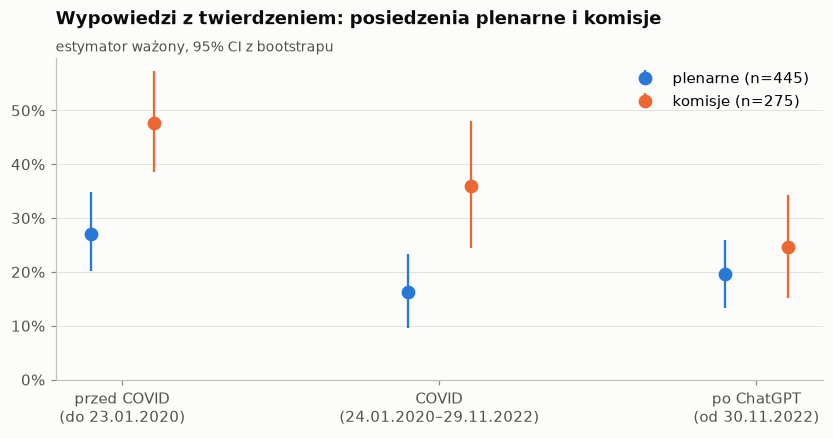

,plenarne,komisje
przed COVID,27.1 [20.2; 34.8],47.7 [38.5; 57.4]
COVID,16.3 [9.6; 23.4],36.0 [24.4; 48.0]
po ChatGPT,19.6 [13.4; 25.9],24.6 [15.1; 34.4]


In [19]:
fig, ax = plt.subplots(figsize=(9, 3.8))
src_tab = {}
for k, (name, color) in enumerate([("plenarne", ACCENT), ("komisje", SECOND)]):
    b = R.bootstrap(subsets[name], "okres").loc[PERIODS]
    src_tab[name] = fmt_ci(b)
    x = np.arange(len(PERIODS)) + (k - 0.5) * 0.2
    ax.errorbar(x, b["p"], yerr=[b["p"] - b["lo"], b["hi"] - b["p"]], fmt="o", color=color, ecolor=color,
                elinewidth=1.5, capsize=0, ms=8, label=f"{name} (n={len(subsets[name])})")
ax.set_xticks(range(len(PERIODS)), [PERIOD_TICK[p] for p in PERIODS])
ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, None); ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
ax.set_title("Wypowiedzi z twierdzeniem: posiedzenia plenarne i komisje")
subtitle(ax, "estymator ważony, 95% CI z bootstrapu")
save(fig, "llm_a_plenarne_komisje"); plt.show()
pd.DataFrame(src_tab, index=[PERIOD_LABEL[p] for p in PERIODS])

* Dla całej próby spadek po 2020 r. jest wyraźny w obu miarach: odsetek wypowiedzi z twierdzeniem −12,5 pp (COVID) i −15,0 pp
  (po ChatGPT) względem okresu przed COVID, liczba twierdzeń na 100 wypowiedzi −36 i −47; żaden z tych przedziałów nie obejmuje zera.
* Po rozbiciu na źródła różnice słabną: na posiedzeniach plenarnych istotny jest tylko spadek w okresie COVID
  (−10,9 pp [−21,0; −0,7]), a po ChatGPT odsetek wraca bliżej poziomu sprzed COVID (−7,6 pp [−17,7; +2,1]). W komisjach spadek
  narasta i jest istotny po ChatGPT (−23,2 pp).
* Komisje mają wyższy odsetek w każdym okresie (48% / 36% / 25% wobec 27% / 16% / 20% na posiedzeniach plenarnych), a ich udział
  w próbie spada z 44% do 31%. Część różnicy między okresami to więc efekt składu (więcej komisji i ekspertów przed COVID),
  a nie zmiana sposobu wypowiadania się.
* Wniosek dla planu: estymacja musi uwzględniać źródło wypowiedzi (warstwa w losowaniu albo zmienna w modelu).

### 5.5 Pod kątem pozostałych hipotez: okresy przedwyborcze

Wstępny podgląd dla H2: wypowiedzi z 90 dni przed wyborami do Sejmu, Parlamentu Europejskiego i na prezydenta (pierwsza tura)
w zakresie danych. Wybory do Sejmu 25.10.2015 są przed początkiem danych. Służy ocenie, ile materiału przypada na okna kampanii,
nie testowaniu H2.

In [20]:
ELECTIONS = [("PE", "2019-05-26"), ("Sejm", "2019-10-13"), ("prezydent", "2020-06-28"),
             ("Sejm", "2023-10-15"), ("PE", "2024-06-09"), ("prezydent", "2025-05-18")]
camp = pd.Series(False, index=df.index)
for _, d in ELECTIONS:
    d = pd.Timestamp(d)
    camp |= df["data"].between(d - pd.Timedelta(days=90), d - pd.Timedelta(days=1))
df["kampania"] = np.where(camp, "90 dni przed wyborami", "pozostały czas")
b1, b2 = R.bootstrap(df, "kampania"), R.bootstrap(df, "kampania", y="n_twierdzen")
pd.DataFrame({"n (próba)": b1["n"], "z twierdzeniem [%]": fmt_ci(b1), "twierdzenia / 100 wyp.": fmt_ci(b2),
              "szac. twierdzenia w populacji": R.weighted_total(df, "kampania", y="n_twierdzen").round().astype(int)})

,n (próba),z twierdzeniem [%],twierdzenia / 100 wyp.,szac. twierdzenia w populacji
kampania,,,,
90 dni przed wyborami,90,27.7 [18.3; 38.5],61.9 [36.2; 92.8],1562
pozostały czas,630,24.9 [20.9; 28.7],50.8 [41.3; 61.6],8589


Na okna 90 dni przed wyborami przypada 90 wypowiedzi z próby (12,5%) i ok. 1,6 tys. szacowanych twierdzeń w populacji. Odsetek
wypowiedzi z twierdzeniem nie różni się wyraźnie od reszty czasu (27,7% wobec 24,9%, przedziały się nakładają). Jeśli twierdzenia sprzeczne z konsensusem stanowią
kilka procent, w oknach kampanii będzie ich kilkadziesiąt, więc test H2 wymaga pomiaru na całej populacji, a nie na próbie (10.5).

## 6. Kto mówi

### 6.1 Rola mówcy i miejsce wypowiedzi

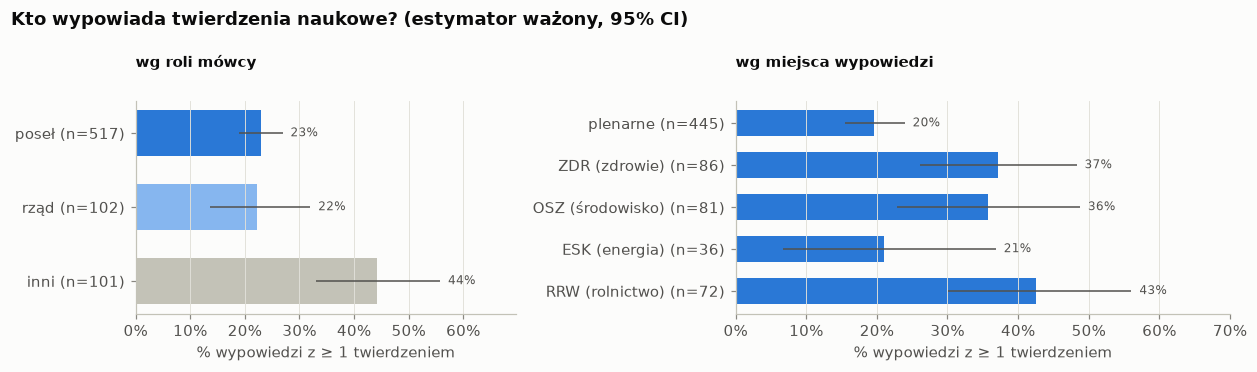

,% wypowiedzi w próbie,% twierdzeń
rola,,
poseł,71.8,49.0
rząd,14.2,13.2
inni,14.0,37.9


In [21]:
b_rola = R.bootstrap(df, "rola").reindex(["poseł", "rząd", "inni"])
b_grem = R.bootstrap(df, "gremium").reindex(list(GREMIA))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.4), gridspec_kw={"width_ratios": [1, 1.3]})
hbar_ci(a1, b_rola, [ROLE_KOLOR[r] for r in b_rola.index], [f"{r} (n={n})" for r, n in zip(b_rola.index, b_rola["n"])])
hbar_ci(a2, b_grem, ACCENT, [f"{GREMIA[g]} (n={n})" for g, n in zip(b_grem.index, b_grem["n"])])
a1.set_title("wg roli mówcy", fontsize=10); a2.set_title("wg miejsca wypowiedzi", fontsize=10)
for ax in (a1, a2):
    ax.set_xlabel("% wypowiedzi z ≥ 1 twierdzeniem")
fig.suptitle("Kto wypowiada twierdzenia naukowe? (estymator ważony, 95% CI)", x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "llm_a_09_rola_miejsce"); plt.show()
role_share = pd.DataFrame({"% wypowiedzi w próbie": df["rola"].value_counts(normalize=True) * 100,
                           "% twierdzeń": cl["rola"].value_counts(normalize=True) * 100}).reindex(["poseł", "rząd", "inni"])
role_share.round(1)

Eksperci i goście (rola „inni”) to 14% wypowiedzi w próbie, ale 38% twierdzeń; twierdzenie ma 44% ich wypowiedzi, wobec 23%
u posłów i 22% u przedstawicieli rządu. Na posiedzeniach plenarnych odsetek wynosi 20%, w komisjach 21–43%. Hipotezy dotyczą polityków, więc decyzja
o tym, kogo liczymy w mianowniku (sami posłowie / posłowie i rząd / wszyscy), wpłynie na wynik (sekcja 10.3).

### 6.2 Bloki polityczne (tylko posłowie)

Kolor oznacza zawsze ten sam blok (paleta z `01`). Liczności bloków w próbie są małe, przedziały szerokie.

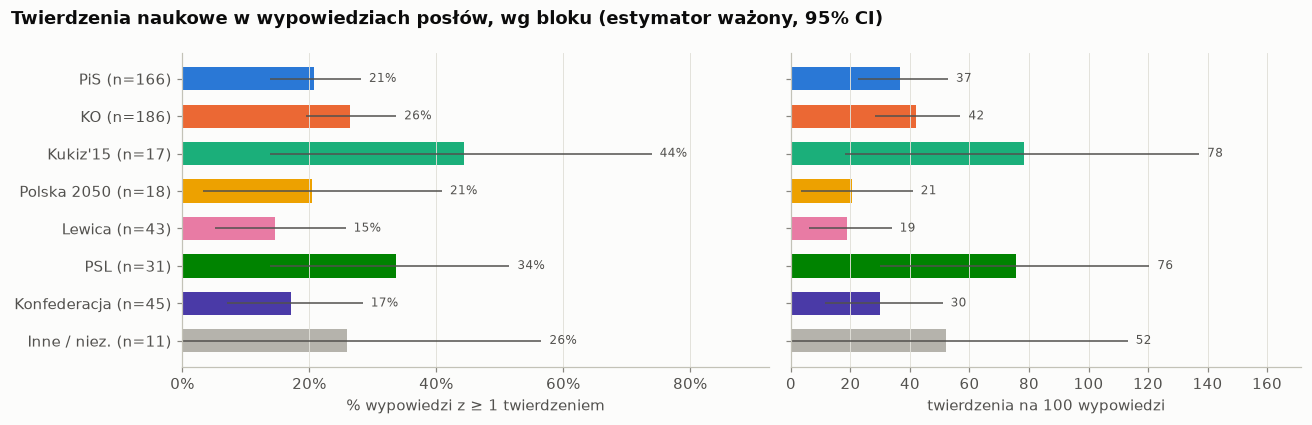

,n,z twierdzeniem [%],twierdzenia / 100 wyp.
blok,,,
PiS,166,20.8 [13.9; 28.2],36.8 [22.7; 52.8]
KO,186,26.4 [19.4; 33.7],42.0 [28.4; 57.0]
Kukiz'15,17,44.4 [13.9; 74.0],78.4 [18.2; 137.2]
Polska 2050,18,20.5 [3.3; 40.9],20.5 [3.3; 40.9]
Lewica,43,14.6 [5.1; 25.7],18.7 [6.1; 33.9]
PSL,31,33.6 [13.9; 51.5],75.5 [29.8; 120.5]
Konfederacja,45,17.1 [7.1; 28.5],29.8 [11.4; 51.0]
Inne / niez.,11,26.0 [0.0; 56.6],51.9 [0.0; 113.2]


In [22]:
pos = df[df["rola"] == "poseł"]
blocs = [b for b in BLOKI if b in set(pos["blok"])]
b1 = R.bootstrap(pos, "blok").reindex(blocs)
b2 = R.bootstrap(pos, "blok", y="n_twierdzen").reindex(blocs)
colors = [BLOK_KOLOR[b] for b in blocs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.15, 1]})
hbar_ci(a1, b1, colors, [f"{b} (n={n})" for b, n in zip(blocs, b1["n"])])
hbar_ci(a2, b2, colors, pct=False)
a1.set_xlabel("% wypowiedzi z ≥ 1 twierdzeniem"); a2.set_xlabel("twierdzenia na 100 wypowiedzi")
fig.suptitle("Twierdzenia naukowe w wypowiedziach posłów, wg bloku (estymator ważony, 95% CI)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "llm_a_10_bloki"); plt.show()
pd.DataFrame({"n": b1["n"], "z twierdzeniem [%]": fmt_ci(b1), "twierdzenia / 100 wyp.": fmt_ci(b2)})

Wśród posłów najwyższe odsetki mają Kukiz'15 i PSL, ale przy n = 17 i 31. Wśród dużych bloków KO ma 26%, PiS 21%,
Konfederacja 17%, Lewica 15%; przedziały w większości się nakładają. Częstość twierdzeń naukowych nie mówi nic o ich trafności:
blok, który rzadko formułuje twierdzenia naukowe, może mieć zarówno niski, jak i wysoki odsetek twierdzeń fałszywych.
Liczności są za małe, żeby dzielić bloki dalej na okresy.

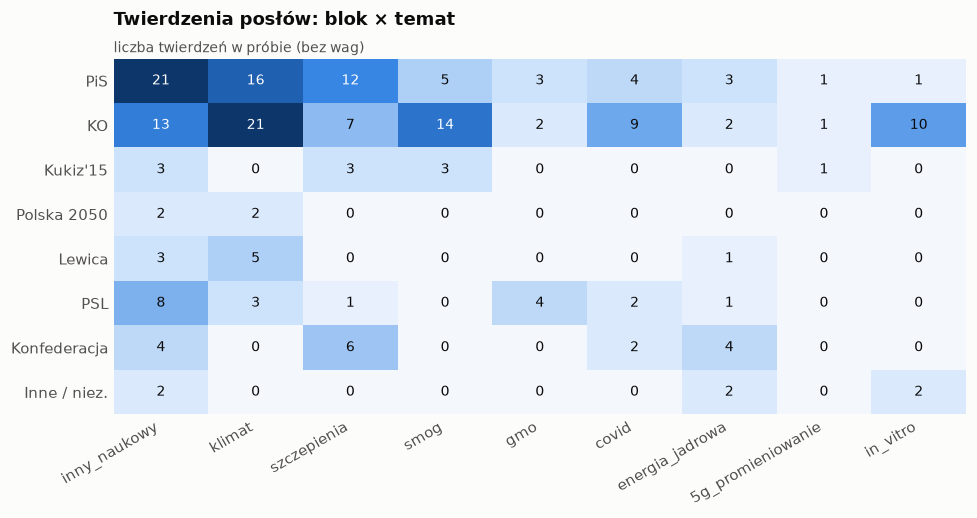

In [23]:
cp = cl[cl["rola"] == "poseł"]
bt = pd.crosstab(cp["blok"], cp["temat"]).reindex(index=blocs, columns=[t for t in topics_tab.index], fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.imshow(bt.values, cmap=SEQ, aspect="auto", vmin=0)
ax.set_xticks(range(bt.shape[1]), bt.columns, rotation=30, ha="right"); ax.set_yticks(range(bt.shape[0]), bt.index)
ax.grid(False); ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
for i in range(bt.shape[0]):
    for j in range(bt.shape[1]):
        v = bt.values[i, j]
        ax.text(j, i, f"{v}", ha="center", va="center", fontsize=9, color="white" if v > bt.values.max() * 0.55 else INK)
ax.set_title("Twierdzenia posłów: blok × temat")
subtitle(ax, "liczba twierdzeń w próbie (bez wag)")
save(fig, "llm_a_11_bloki_tematy"); plt.show()

### 6.3 Mówcy z największą liczbą twierdzeń w próbie

In [24]:
spk = (df.groupby("mowca").agg(rola=("rola", "first"), miejsce=("gremium", lambda s: "/".join(sorted(set(s)))),
                               wypowiedzi=("y", "size"), twierdzenia=("n_twierdzen", "sum"))
       .sort_values("twierdzenia", ascending=False).head(10))
spk.index = spk.index.str.slice(0, 90)
spk

,rola,miejsce,wypowiedzi,twierdzenia
mowca,,,,
Kierownik Zakładu Chorób Świń Państwowego Instytutu Weterynaryjnego – Państwowego Instytut,inni,RRW,1,15
Zastępca dyrektora Departamentu Monitoringu Środowiska Głównego Inspektoratu Ochrony Środo,inni,OSZ,1,8
Zastępca prezesa PGW Wody Polskie Joanna Kopczyńska,inni,OSZ,1,7
Pracownik naukowy Uniwersytetu Przyrodniczego w Poznaniu i Instytutu Genetyki Roślin Polsk,inni,RRW,1,7
Jarosław Pinkas,rząd,plenarne,2,7
Ewa Lieder,poseł,plenarne,6,7
Podsekretarz stanu w MKiŚ Piotr Dziadzio,rząd,OSZ,1,7
Kierownik Zakładu Biologicznych Metod IOR-PIB prof. dr hab. Marek Tomalak,inni,RRW,1,6
Kierownik Zakładu Fizjologii Pracy i Ergonomii Instytutu Medycyny Pracy prof. Alicja Bortk,inni,OSZ,1,6


Na liście dominują goście komisji (Państwowy Instytut Weterynaryjny, GIOŚ, Wody Polskie, Instytut Ochrony Roślin, Instytut
Medycyny Pracy), a nie posłowie. Jedna rozbudowana wypowiedź eksperta daje kilka do kilkunastu twierdzeń.

## 7. Słowniki a LLM

Czy trafienia słowników (podstawa analizy w `01`) przewidują obecność twierdzeń naukowych? Odsetki bez wag.

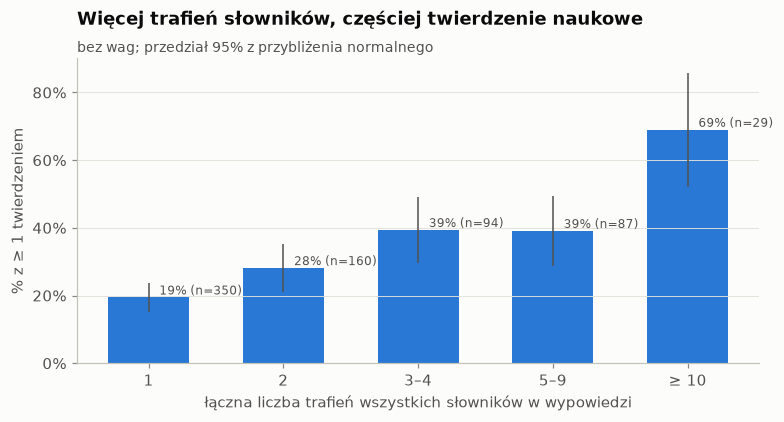

,n,z twierdzeniem [%],twierdzenia / 100 wyp.
trafienie słownika tematu (≥ 1),594.0,26.8,55.9
wypowiedź tematyczna z 01 (≥ 3 trafienia tematu),179.0,43.0,104.5
"tylko marker nauka / sceptycyzm, bez tematu",126.0,35.7,86.5
marker nauka > 0,161.0,43.5,116.1
marker nauka = 0,559.0,24.0,45.4
marker sceptycyzm > 0,8.0,37.5,62.5


In [25]:
df["trafienia"] = pd.cut(df[sampling.HIT_COLS].sum(axis=1), [1, 2, 3, 5, 10, np.inf],
                         labels=["1", "2", "3–4", "5–9", "≥ 10"], right=False)
hits = df.groupby("trafienia", observed=True).agg(n=("y", "size"), p=("y", "mean"))
se = np.sqrt(hits["p"] * (1 - hits["p"]) / hits["n"])
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(hits))
ax.bar(x, hits["p"], color=ACCENT, width=0.6)
ax.errorbar(x, hits["p"], yerr=1.96 * se, fmt="none", ecolor=INK2, elinewidth=1, capsize=0)
for xi, (p, n) in enumerate(zip(hits["p"], hits["n"])):
    ax.text(xi + 0.08, p, f"{p:.0%} (n={n})", fontsize=8, color=INK2, va="bottom")
ax.set_xticks(x, hits.index); ax.yaxis.set_major_formatter(PCT); ax.grid(axis="x", visible=False)
ax.set_xlabel("łączna liczba trafień wszystkich słowników w wypowiedzi"); ax.set_ylabel("% z ≥ 1 twierdzeniem")
ax.set_title("Więcej trafień słowników, częściej twierdzenie naukowe")
subtitle(ax, "bez wag; przedział 95% z przybliżenia normalnego")
save(fig, "llm_a_12_regex_vs_llm"); plt.show()

topic_hit = df[TOPICS].gt(0).any(axis=1)
groups = {
    "trafienie słownika tematu (≥ 1)": topic_hit,
    "wypowiedź tematyczna z 01 (≥ 3 trafienia tematu)": df[TOPICS].ge(T.PROG).any(axis=1),
    "tylko marker nauka / sceptycyzm, bez tematu": ~topic_hit,
    "marker nauka > 0": df["nauka"].gt(0),
    "marker nauka = 0": df["nauka"].eq(0),
    "marker sceptycyzm > 0": df["sceptycyzm"].gt(0),
}
pd.DataFrame({k: {"n": int(m.sum()), "z twierdzeniem [%]": 100 * df.loc[m, "y"].mean(),
                  "twierdzenia / 100 wyp.": 100 * df.loc[m, "n_twierdzen"].mean()} for k, m in groups.items()}).T.round(1)

* Liczba trafień przewiduje twierdzenie tylko umiarkowanie: przy jednym trafieniu twierdzenie ma 19% wypowiedzi, przy co najmniej
  dziesięciu 69%. Nawet „wypowiedź tematyczna” z `01` (≥ 3 trafienia tematu) zawiera twierdzenie naukowe tylko w 43% przypadków.
* Marker `nauka` podnosi odsetek z 24% do 44%. Wypowiedzi, które przeszły filtr wyłącznie dzięki markerom `nauka` / `sceptycyzm`,
  mają twierdzenie częściej niż te ze słownikiem tematu (36% wobec 27%), więc markery są użyteczną częścią filtra.
* Marker `sceptycyzm` wystąpił w próbie tylko w 8 wypowiedziach. Losowanie bez warstwy po markerze nie da materiału do analizy
  języka podważającego naukę.
* Słowniki mierzą temat rozmowy, a nie obecność twierdzenia. Jako filtr wstępny przepuszczają dużo wypowiedzi bez twierdzeń,
  a ich czułości (ile twierdzeń jest poza filtrem) jeszcze nie znamy (wymagałoby to anotacji wypowiedzi spoza filtra).

## 8. Atrybucja (cytaty)

Czy mówca twierdzi sam, czy przytacza cudze twierdzenie (z aprobatą lub w polemice). W polemice etap B oceni stanowisko mówcy.

In [26]:
display(cl["atrybucja"].value_counts().to_frame("twierdzenia"))
cl.loc[cl["atrybucja"] != "wlasne", ["rok", "atrybucja", "cytat", "twierdzenie"]]

,twierdzenia
atrybucja,
wlasne,424
cytat_zgoda,14
cytat_polemika,3


,rok,atrybucja,cytat,twierdzenie
37,2015,cytat_zgoda,Poinformowano mnie o zmianach refundacyjnych utrudniających dostęp dzieci po transplantacjach do leku - i tu jego nazwa. To niepokojące i z medycznego punktu widzenia w najlepiej pojętym interesie...,"Zmiany refundacyjne utrudniają dostęp dzieci po transplantacjach do niezbędnych leków, co jest niebezpieczne z medycznego punktu widzenia."
38,2015,cytat_zgoda,"Podanie, co wymusi sytuacja finansowa, niebadanego nigdy w tej grupie wiekowej kolejnego leku odtwórczego dzieciom po transplantacji, utrzymywanym długotrwale bez steroidów - uwaga, cytat - jest o...",Stosowanie nieprzebadanych leków u dzieci po transplantacjach wiąże się z ryzykiem odrzucenia przeszczepu.
56,2016,cytat_zgoda,"Dwustu specjalistów z 39 krajów świata alarmuje, że winne są temu urządzenia bezprzewodowe będące źródłem promieniowania elektromagnetycznego.","Dwustu specjalistów z 39 krajów twierdzi, że urządzenia bezprzewodowe emitujące promieniowanie elektromagnetyczne są przyczyną wzrostu nowotworów mózgu."
69,2016,cytat_zgoda,"Proszę zapoznać się z opinią Światowej Organizacji Zdrowia. Jest taka organizacja. Nie wiem, czy pani o tym wie, ale jest Światowa Organizacja Zdrowia, która uznaje in vitro za metodę leczenia.",Światowa Organizacja Zdrowia uznaje in vitro za metodę leczenia.
74,2016,cytat_zgoda,"Gdyby przyszło mi zrobić tylko jedną rzecz jako ministrowi zdrowia, to ta jedna rzecz to istotne ograniczenie palenia tytoniu. Z tego będzie największy profit zdrowotny.",Ograniczenie palenia tytoniu przyniesie największe korzyści zdrowotne.
83,2016,cytat_zgoda,"naukowcy projektowali rozwój tego sektora, to twierdzili, że powinniśmy osiągnąć mniej więcej 500 tys. ha zasiewu, żeby mniej więcej w połowie zabezpieczyć nasze potrzeby białkowe.","Naukowcy twierdzili, że dla zabezpieczenia połowy potrzeb białkowych Polski potrzeba około 500 tys. ha zasiewów roślin wysokobiałkowych."
183,2018,cytat_polemika,"Proponuję, żeby jeszcze przygotować inicjatywę przeciwko teorii Kopernika, bo jak widać, przecież Słońce krąży wokół Ziemi","Teoria geocentryczna (Słońce krąży wokół Ziemi) jest fałszywa, a teoria heliocentryczna Kopernika jest prawdziwa."
184,2018,cytat_polemika,"przeciwko transfuzji krwi, teorii ewolucji, przeciwko kolei żelaznej, która była określona jako dzieło szatana i musi być potępiona, przeciwko oświetleniu ulic w nocy, dlatego że jest to wbrew nat...","Teoria ewolucji, transfuzja krwi, kolej żelazna i oświetlenie ulic są zgodne z nauką i nie są sprzeczne z naturą."
257,2019,cytat_zgoda,"Eksperci Europejskiego Urzędu ds. Bezpieczeństwa Żywności mówią, że nieprawidłowo wykonywany, nieracjonalny odstrzał dzików będzie przyczyniał się do rozprzestrzeniania epidemii.","Nieracjonalny odstrzał dzików zwiększa ryzyko rozprzestrzeniania się ASF, co potwierdzają eksperci EFSA."
258,2019,cytat_zgoda,"EFSA, główny lekarz weterynarii nakazali niewykonywanie tam polowań zbiorowych.",EFSA i główny lekarz weterynarii zalecają unikanie polowań zbiorowych w strefach zagrożonych ASF.


424 z 441 twierdzeń to twierdzenia własne mówcy. Cytatów z aprobatą jest 14, w polemice 3. Polemika to tu m.in. ironia
(„przecież Słońce krąży wokół Ziemi”), czyli przypadek, w którym etap B musi ocenić stanowisko mówcy, a nie dosłowne zdanie.
Wśród cytatów z aprobatą są odwołania do instytucji (EMA, WHO, EFSA, sekretarz generalny ONZ), ale też, w 2026 r., przytoczone
z aprobatą twierdzenia o szczepionkach mRNA i „udowodnionej” szkodliwości szczepień: kandydaci na twierdzenia sprzeczne
z konsensusem, które atrybucja `cytat_zgoda` pozwala przypisać mówcy.

## 9. Źródła błędu i problemy

Bez ręcznej anotacji nie zmierzymy precyzji ani czułości, ale część błędów widać w samych danych. Najważniejsze pytanie dla H1:
czy błąd jest **taki sam w porównywanych okresach**. Błąd różnicowy może sam wytworzyć albo ukryć różnicę między okresami.
Sekcje 9.1–9.3 opisują problemy znalezione w pierwszym przebiegu i efekt ich naprawy, 9.4–9.8 problemy, które zostają.

### 9.1 Przepełnienie kontekstu w pierwszym przebiegu

Prompt kroku 1 (instrukcje i przykłady), wypowiedź i odpowiedź modelu muszą się zmieścić w kontekście. W pierwszym przebiegu
kontekst miał 8192 tokeny i przy dłuższych wypowiedziach się nie mieścił, a Ollama nie zgłaszała błędu. Były dwa warianty:

1. **Obcięte wejście** (flaga `przepelnienie`): sam prompt był dłuższy niż 8192 tokeny. Ollama skracała go do 4098 tokenów,
   zostawiając 4 pierwsze tokeny i **koniec** tekstu. Wypadał cały prompt systemowy i początek wypowiedzi; model dostawał fragment
   wypowiedzi bez żadnych instrukcji, a schemat JSON wymuszał tylko format odpowiedzi. W danych: `tokeny_we = 4098`.
2. **Przesunięcie kontekstu pod koniec odpowiedzi** (flaga `przesuniecie`): prompt się mieścił, ale prompt + odpowiedź już nie.
   llama-server (silnik Ollamy) usuwał wtedy najstarsze tokeny, czyli instrukcje, i generował dalej. Dotyczyło to tylko końcówki
   odpowiedzi (ostatnich kandydatów). W danych: `tokeny_we + tokeny_wy > 8192`.

Log Ollamy z pierwszego przebiegu:

```
level=WARN source=llama_server.go:320 msg="truncating input prompt" limit=4098 prompt=9764 keep=4 new=4098
slot operator(): id 0 | task 18 | slot context shift, n_keep = 4, n_left = 8187, n_discard = 4093
```

prompt bazowy ≈ 4698 tokenów + 2.92 tokenu na słowo wypowiedzi; przy 8192 tokenach mieściło się ok. 1195 słów
obcięte wejście: 66 wypowiedzi (9.2%), od 1155 słów; przesunięcie kontekstu: 26 (709–1282 słów)


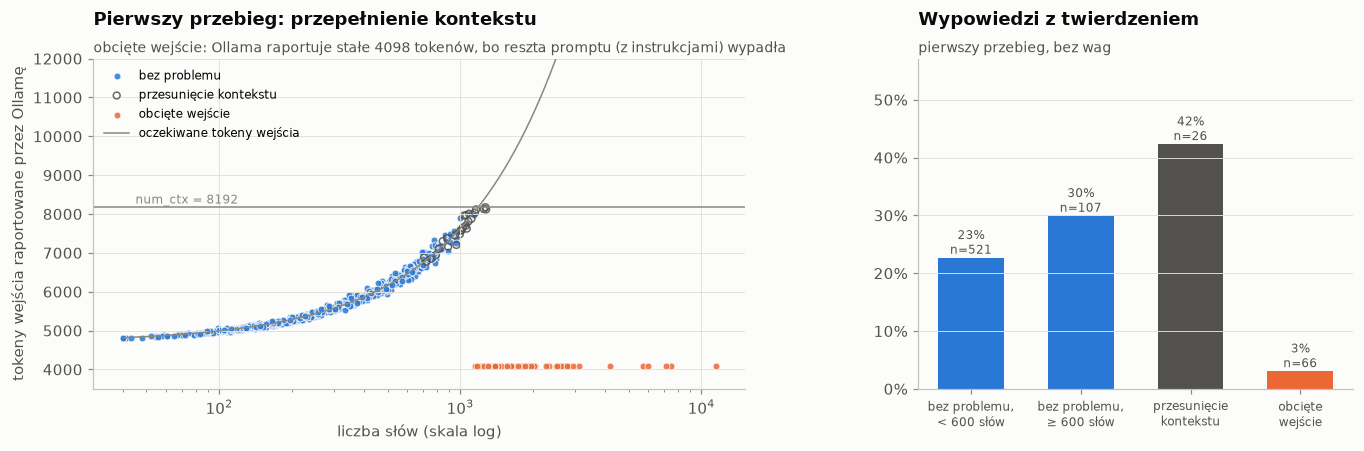

obcięte wejście [%]  przesunięcie kontekstu [%]
okres  przed COVID                 11.1                         4.3
       COVID                        8.2                         3.5
       po ChatGPT                   7.3                         2.9
źródło komisje                     11.3                         5.1
       plenarne                     7.9                         2.7

**Rodzaje kandydatów w pierwszym przebiegu (% wiersza)**

rodzaj,budzet,inne,naukowe,opinia,polityka,prawo,statystyka
row_0,,,,,,,
bez problemu,2.4,7.4,43.9,12.6,19.2,4.5,9.9
obcięte wejście,1.3,38.6,2.9,7.0,32.9,15.1,2.1
przesunięcie kontekstu,2.4,12.6,49.1,2.4,11.4,4.8,17.4


,wypowiedz_id,rodzaj,cytat
1014,9_ZDR_19_21,inne,Platforma Obywatelska za swój największy sukces w walce ze świńską grypą uznała nieprzystąpienie do unijnych zakupów szczepionek.
744,8_74_2018-12-12_4,polityka,"Bardzo dziękuję panu ministrowi Błaszczakowi, ale też jego poprzednikowi, za umacnianie polskiej armii. Dziękuję panu ministrowi Macierewiczowi za to, co zrobił wcześniej. To naprawdę wielkie zasł..."
55,8_3_2015-12-02_68,prawo,"ustawa, którą mam zaszczyt prezentować, wykonuje wyrok Trybunału Konstytucyjnego."
17,8_1_2015-11-18_3,polityka,"W ostatnich tygodniach Platforma była pytana, jaką będziemy opozycją. To było pytanie, które zadawali eksperci, dziennikarze i ludzie na ulicach. Czy będziemy taką totalną opozycją, jaką wy byliśc..."
929,8_86_2019-09-11_209,inne,Rzecznik Praw Obywatelskich Adam Bodnar
987,9_9_2020-04-06_5,polityka,"Relatywnie niska liczba zachorowań nie powoduje, że nasza uwaga jest dzisiaj uśpiona, bo zdajemy sobie sprawę z tego, że pandemia może przyspieszyć, może się wypłaszczyć."


In [27]:
f_fine = ~first["przepelnienie"] & ~first["przesuniecie"]
slope, intercept = np.polyfit(first.loc[~first["przepelnienie"], "liczba_slow"], first.loc[~first["przepelnienie"], "tokeny_we"], 1)
print(f"prompt bazowy ≈ {intercept:.0f} tokenów + {slope:.2f} tokenu na słowo wypowiedzi; "
      f"przy 8192 tokenach mieściło się ok. {(8192 - intercept) / slope:.0f} słów")
print(f"obcięte wejście: {first['przepelnienie'].sum()} wypowiedzi ({first['przepelnienie'].mean():.1%}), "
      f"od {first.loc[first['przepelnienie'], 'liczba_slow'].min()} słów; przesunięcie kontekstu: {first['przesuniecie'].sum()} "
      f"({first.loc[first['przesuniecie'], 'liczba_slow'].min()}–{first.loc[first['przesuniecie'], 'liczba_slow'].max()} słów)")

GROUPS = ["bez problemu, < 600 słów", "bez problemu, ≥ 600 słów", "przesunięcie kontekstu", "obcięte wejście"]
grp = pd.Series(np.select([first["przepelnienie"], first["przesuniecie"], first["liczba_slow"] >= 600], GROUPS[:0:-1], GROUPS[0]),
                index=first.index)
g = first.assign(g=grp).groupby("g").agg(n=("y", "size"), p=("y", "mean")).loc[GROUPS]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
for mask, color, face, lab in [(f_fine, ACCENT, ACCENT, "bez problemu"), (first["przesuniecie"], INK2, "none", "przesunięcie kontekstu"),
                               (first["przepelnienie"], SECOND, SECOND, "obcięte wejście")]:
    a1.scatter(first.loc[mask, "liczba_slow"], first.loc[mask, "tokeny_we"], s=20, facecolor=face,
               edgecolor=color if face == "none" else SURF, linewidth=1 if face == "none" else 0.6, alpha=0.85, label=lab)
xs = np.linspace(40, 2500, 200)
a1.plot(xs, intercept + slope * xs, color=MUTED, lw=1, label="oczekiwane tokeny wejścia")
a1.axhline(8192, color=MUTED, lw=1)
a1.text(45, 8192, "num_ctx = 8192", fontsize=8, color=MUTED, va="bottom")
a1.set_xscale("log"); a1.set_ylim(3500, 12000)
a1.set_xlabel("liczba słów (skala log)"); a1.set_ylabel("tokeny wejścia raportowane przez Ollamę")
a1.legend(loc="upper left", fontsize=8)
a1.set_title("Pierwszy przebieg: przepełnienie kontekstu")
subtitle(a1, "obcięte wejście: Ollama raportuje stałe 4098 tokenów, bo reszta promptu (z instrukcjami) wypadła")
x = np.arange(len(g))
a2.bar(x, g["p"], color=[ACCENT, ACCENT, INK2, SECOND], width=0.6)
for xi, (p, n) in enumerate(zip(g["p"], g["n"])):
    a2.text(xi, p, f"{p:.0%}\nn={n}", ha="center", va="bottom", fontsize=8, color=INK2)
a2.set_xticks(x, [s.replace(", ", ",\n").replace(" kontekstu", "\nkontekstu").replace(" wejście", "\nwejście") for s in g.index], fontsize=8)
a2.yaxis.set_major_formatter(PCT); a2.set_ylim(0, g["p"].max() * 1.35); a2.grid(axis="x", visible=False)
a2.set_title("Wypowiedzi z twierdzeniem")
subtitle(a2, "pierwszy przebieg, bez wag")
fig.tight_layout()
save(fig, "llm_a_13_przepelnienie"); plt.show()

display(pd.concat({
    "okres": first.groupby("okres")[["przepelnienie", "przesuniecie"]].mean().loc[PERIODS].rename(index=PERIOD_LABEL),
    "źródło": first.groupby("zrodlo")[["przepelnienie", "przesuniecie"]].mean(),
}).mul(100).round(1).rename(columns={"przepelnienie": "obcięte wejście [%]", "przesuniecie": "przesunięcie kontekstu [%]"}))
f_cand = R.candidates(first)
status3 = np.select([f_cand["przepelnienie"], f_cand["przesuniecie"]], ["obcięte wejście", "przesunięcie kontekstu"], "bez problemu")
display(Markdown("**Rodzaje kandydatów w pierwszym przebiegu (% wiersza)**"),
        pd.crosstab(status3, f_cand["rodzaj"], normalize="index").mul(100).round(1))
f_cand.loc[f_cand["przepelnienie"], ["wypowiedz_id", "rodzaj", "cytat"]].sample(6, random_state=2)

* **Obcięte wejście było krytyczne.** Dotyczyło 66 wypowiedzi (9%), wszystkich od ok. 1150 słów, w tym 15 ucinanych do 2500 słów.
  Tylko 3% ich kandydatów to zdania „naukowe” (wobec 44%), za to 39% to „inne” i 33% „polityka”, np. „Rzecznik Praw Obywatelskich
  Adam Bodnar” jako kandydat. Twierdzenie miało 3% tych wypowiedzi, wobec 30% dla długich wypowiedzi bez problemu.
* **Przesunięcie kontekstu było mniej groźne.** 26 wypowiedzi (709–1282 słów); instrukcje wypadały dopiero przy ostatnich
  kandydatach, a rozkład rodzajów był podobny do reszty.
* **Błąd był różnicowy.** Obcięte wejście dotyczyło 11% wypowiedzi przed COVID, 8% w okresie COVID i 7% po ChatGPT, oraz częściej
  komisji niż posiedzeń plenarnych, więc zaniżało przede wszystkim okres przed COVID.
* Oba błędy były ciche: odpowiedź miała poprawny JSON i skrypt nie zgłaszał błędu. Wykryliśmy je dopiero przez analizę długości
  wypowiedzi i liczby tokenów.

### 9.2 Naprawa i jej efekt

* Kontekst zwiększony do 16 384 tokenów dla obu kroków (model z takim kontekstem mieści się w 12 GB VRAM). Zmieści się prompt
  z wypowiedzią do 2500 słów i odpowiedzią do 4096 tokenów.
* Skrypt porównuje liczbę tokenów raportowaną przez Ollamę z rozmiarem kontekstu i oznacza każde przepełnienie jako błąd,
  żeby problem nie wrócił po cichu.
* Ponownie sklasyfikowaliśmy 119 wypowiedzi: z obciętym wejściem, z przesunięciem kontekstu albo z pełnym limitem kandydatów (9.3).

Porównanie tych 119 wypowiedzi przed i po naprawie (ten sam model i prompt):

,pierwszy przebieg,po naprawie
wypowiedzi,119.0,119.0
z twierdzeniem [%],21.8,46.2
twierdzenia,60.0,160.0
kandydaci na wypowiedź,6.4,6.8
kandydaci „naukowe” [%],20.4,46.0
obcięte wejście,66.0,0.0
przesunięcie kontekstu,26.0,0.0


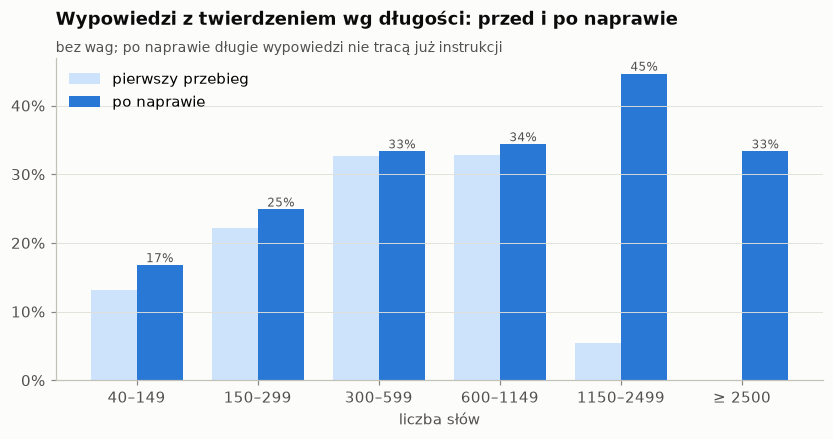

In [28]:
def summary(d):
    c = R.candidates(d)
    return pd.Series({"wypowiedzi": len(d), "z twierdzeniem [%]": 100 * d["y"].mean(), "twierdzenia": int(d["n_twierdzen"].sum()),
                      "kandydaci na wypowiedź": d["n_kandydatow"].mean(), "kandydaci „naukowe” [%]": 100 * c["rodzaj"].eq("naukowe").mean(),
                      "obcięte wejście": int(d["przepelnienie"].sum()), "przesunięcie kontekstu": int(d["przesuniecie"].sum())})

fix = pd.DataFrame({"pierwszy przebieg": summary(first[first["wypowiedz_id"].isin(rerun_ids)]),
                    "po naprawie": summary(df[df["wypowiedz_id"].isin(rerun_ids)])}).round(1)
display(fix)

fl = first.assign(przebieg="pierwszy przebieg", dlugosc=pd.cut(first["liczba_slow"], LEN_BINS, labels=LEN_LABELS, right=False))
both = pd.concat([fl, df.assign(przebieg="po naprawie")], ignore_index=True)
by_len2 = both.groupby(["dlugosc", "przebieg"], observed=True)["y"].mean().unstack()
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(by_len2)); w = 0.38
for k, (col, color) in enumerate([("pierwszy przebieg", ACCENT_LIGHT), ("po naprawie", ACCENT)]):
    ax.bar(x + (k - 0.5) * w, by_len2[col], width=w, color=color, label=col)
for xi, v in enumerate(by_len2["po naprawie"]):
    ax.text(xi + w / 2, v, f"{v:.0%}", ha="center", va="bottom", fontsize=8, color=INK2)
ax.set_xticks(x, by_len2.index); ax.yaxis.set_major_formatter(PCT); ax.grid(axis="x", visible=False)
ax.set_xlabel("liczba słów"); ax.legend(loc="upper left")
ax.set_title("Wypowiedzi z twierdzeniem wg długości: przed i po naprawie")
subtitle(ax, "bez wag; po naprawie długie wypowiedzi nie tracą już instrukcji")
save(fig, "llm_a_14_naprawa"); plt.show()

W 119 powtórzonych wypowiedziach odsetek z twierdzeniem wzrósł z 22% do 46%, liczba twierdzeń z 60 do 160, a udział
kandydatów „naukowe” z 20% do 46%. Po naprawie odsetek rośnie z długością aż do najdłuższych wypowiedzi, zamiast się załamywać.

Wpływ na porównanie okresów (cała próba; „po naprawie” obejmuje też nowy krok 2, sekcja 9.4):

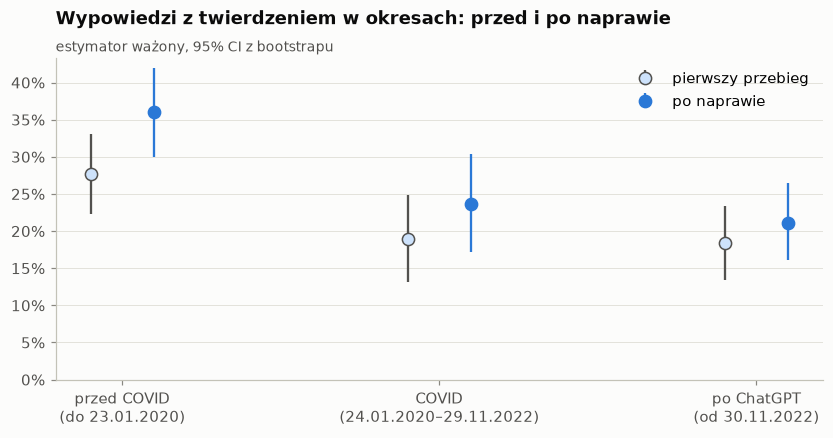

,pierwszy przebieg,po naprawie
przed COVID,27.7 [22.3; 33.0],36.1 [30.0; 41.9]
COVID,18.9 [13.1; 24.9],23.6 [17.2; 30.4]
po ChatGPT,18.4 [13.5; 23.4],21.1 [16.1; 26.5]


wariant,pierwszy przebieg,po naprawie
porównanie,,
COVID − przed COVID,-8.8 [-16.7; -0.9],-12.5 [-21.2; -3.5]
po ChatGPT − COVID,-0.5 [-8.4; +7.0],-2.5 [-11.0; +5.8]
po ChatGPT − przed COVID,-9.3 [-16.6; -1.9],-15.0 [-22.6; -7.2]


In [29]:
fig, ax = plt.subplots(figsize=(9, 3.8))
sens, diffs = {}, []
for k, (name, d, color) in enumerate([("pierwszy przebieg", first, ACCENT_LIGHT), ("po naprawie", df, ACCENT)]):
    b = R.bootstrap(d, "okres").loc[PERIODS]
    sens[name] = fmt_ci(b)
    x = np.arange(len(PERIODS)) + (k - 0.5) * 0.2
    ax.errorbar(x, b["p"], yerr=[b["p"] - b["lo"], b["hi"] - b["p"]], fmt="o", color=color if k else INK2, ecolor=color if k else INK2,
                mfc=color, elinewidth=1.5, capsize=0, ms=8, label=name)
    for a, bb in PAIRS:
        est, lo, hi = R.bootstrap_diff(d, "okres", a, bb)
        diffs.append({"wariant": name, "porównanie": f"{PERIOD_LABEL[bb]} − {PERIOD_LABEL[a]}",
                      "różnica [pp]": f"{100 * est:+.1f} [{100 * lo:+.1f}; {100 * hi:+.1f}]"})
ax.set_xticks(range(len(PERIODS)), [PERIOD_TICK[p] for p in PERIODS])
ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, None); ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
ax.set_title("Wypowiedzi z twierdzeniem w okresach: przed i po naprawie")
subtitle(ax, "estymator ważony, 95% CI z bootstrapu")
save(fig, "llm_a_15_okresy_przed_po"); plt.show()
display(pd.DataFrame(sens, index=[PERIOD_LABEL[p] for p in PERIODS]))
pd.DataFrame(diffs).pivot(index="porównanie", columns="wariant", values="różnica [pp]")[["pierwszy przebieg", "po naprawie"]]

Naprawa podniosła udział we wszystkich okresach, najbardziej przed COVID (27,7% → 36,1%), bo tam przepełnień było najwięcej.
Różnica COVID − przed COVID pogłębiła się z −8,8 do −12,5 pp, a po ChatGPT − przed COVID z −9,3 do −15,0 pp. Kierunek się
nie zmienił, ale wielkość efektu zależała od błędu instrumentu, który nierówno dotykał okresy. To dobry przykład, dlaczego błąd
trzeba mierzyć osobno w każdym okresie.

### 9.3 Limit kandydatów

W pierwszym przebiegu schemat pozwalał na 8 kandydatów. Wypowiedzi z pełnym limitem mogły mieć niewypisane twierdzenia.
Limit podnieśliśmy do 16 i powtórzyliśmy wypowiedzi, które go zapełniły. Krótsze wypowiedzi nie zbliżały się do limitu, więc ich
nie powtarzaliśmy. Alternatywą byłoby wypisywanie wyłącznie zdań „naukowych”, ale to zmienia prompt i wymaga powtórzenia całej
próby, a etykiety pozostałych rodzajów są potrzebne do analizy błędów.

In [30]:
was_full = set(first.loc[first["n_kandydatow"] >= 8, "wypowiedz_id"])
after = df[df["wypowiedz_id"].isin(was_full)]
pos = after["kandydaci"].apply(lambda cs: sum(1 for k, c in enumerate(cs) if k >= 8 and c.get("weryfikacja")))
print(f"pełny limit 8 w pierwszym przebiegu: {len(was_full)} wypowiedzi, w tym {first.loc[first['wypowiedz_id'].isin(was_full), 'przepelnienie'].sum()} z obciętym wejściem")
print(f"po naprawie: pełny limit 16: {int((df['n_kandydatow'] >= 16).sum())} wypowiedzi; "
      f"twierdzenia z kandydatów na pozycjach 9–16: {int(pos.sum())} (w {int((pos > 0).sum())} wypowiedziach)")
after["n_kandydatow"].value_counts().sort_index().rename("wypowiedzi").to_frame().T

pełny limit 8 w pierwszym przebiegu: 67 wypowiedzi, w tym 30 z obciętym wejściem
po naprawie: pełny limit 16: 4 wypowiedzi; twierdzenia z kandydatów na pozycjach 9–16: 15 (w 5 wypowiedziach)


n_kandydatow,0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
wypowiedzi,11,1,1,3,4,3,6,13,2,7,3,3,4,2,1,3


W pierwszym przebiegu limit 8 zapełniło 67 wypowiedzi, z czego 30 miało obcięte wejście (zapełniały limit przypadkowymi
zdaniami). Po podniesieniu limitu do 16 zapełniają go tylko 4 wypowiedzi. Kandydaci na pozycjach 9–16 dali 15 twierdzeń
w 5 wypowiedziach: limit 8 gubił niewiele twierdzeń, ale nie zero.

### 9.4 Krok 2 z kontekstem

W pierwszym przebiegu krok 2 oceniał samą parafrazę. Teraz dostaje też fragment wypowiedzi (zdanie z cytatem i po jednym zdaniu
przed i po). Dla wypowiedzi, których nie powtarzaliśmy, mamy obie decyzje dla tych samych kandydatów:

In [31]:
nauk = cand[cand["rodzaj"] == "naukowe"].assign(weryfikacja=lambda x: x["weryfikacja"].astype(bool))
both2 = nauk[nauk["weryfikacja_v0"].notna()].assign(weryfikacja_v0=lambda x: x["weryfikacja_v0"].astype(bool))
lab = {True: "tak", False: "nie"}
display(pd.crosstab(both2["weryfikacja_v0"].map(lab).rename("bez kontekstu (v0)"),
                    both2["weryfikacja"].map(lab).rename("z kontekstem (v1)"), margins=True, margins_name="razem"))
flip = both2.assign(zmiana=both2["weryfikacja_v0"] != both2["weryfikacja"])
display(pd.concat({
    "okres": flip.groupby("okres").agg(kandydaci=("zmiana", "size"), v0_tak=("weryfikacja_v0", "mean"), v1_tak=("weryfikacja", "mean"),
                                       zmiana=("zmiana", "mean")).loc[PERIODS].rename(index=PERIOD_LABEL),
    "źródło": flip.groupby("zrodlo").agg(kandydaci=("zmiana", "size"), v0_tak=("weryfikacja_v0", "mean"), v1_tak=("weryfikacja", "mean"),
                                         zmiana=("zmiana", "mean")),
}).round(2))
cols = ["rok", "temat", "twierdzenie", "cytat"]
display(Markdown("**v0: tak → v1: nie**"), both2.loc[both2["weryfikacja_v0"] & ~both2["weryfikacja"], cols].sample(8, random_state=0))
display(Markdown("**v0: nie → v1: tak**"), both2.loc[~both2["weryfikacja_v0"] & both2["weryfikacja"], cols].sample(8, random_state=0))

z kontekstem (v1),nie,tak,razem
bez kontekstu (v0),,,
nie,290,56,346
tak,30,225,255
razem,320,281,601


kandydaci  v0_tak  v1_tak  zmiana
okres  przed COVID        310    0.44    0.50    0.17
       COVID              102    0.44    0.47    0.13
       po ChatGPT         189    0.40    0.41    0.11
źródło komisje            302    0.50    0.52    0.15
       plenarne           299    0.35    0.41    0.14

**v0: tak → v1: nie**

,rok,temat,twierdzenie,cytat
48,2015,energia_jadrowa,Przesył nadwyżek energii wiatrowej przez Polskę powoduje problemy z przepływami fal wiatrakowych.,Mamy dużo kłopotów związanych z przepływami fal wiatrakowych.
2039,2026,inny_naukowy,"Wino, jako alkohol, może być wstępem do uzależnień.","My próbujemy promować przemysł winiarski, a wino jest alkoholem i często jest wstępem do uzależnień"
749,2018,smog,Smog w Polsce jest długotrwałym problemem środowiskowym.,"Problem smogu, który występuje w Polsce, nie jest problemem nowym."
658,2018,szczepienia,Nieszczepienie się może prowadzić do odrodzenia się chorób zakaźnych.,"W jakim stopniu należy przewidywać zagrożenie faktem, że osoby nie będą się szczepiły, jeśli będą miały taką możliwość, i co to będzie oznaczało, czy ewentualne odrodzenie się tych chorób zakaźnyc..."
1716,2024,smog,"Funkcjonowanie zakładu produkcyjnego w Turku powoduje uciążliwości zapachowe, które wpływają negatywnie na zdrowie i komfort mieszkańców.",Mieszkańcy miasta Turek już od kilku lat są zmuszeni do znoszenia uciążliwości zapachowych związanych z funkcjonowaniem jednego z zakładów produkcyjnych zlokalizowanych na jego terenie.
1547,2023,in_vitro,"Leczenie niepłodności polega na usunięciu przyczyn braku potomstwa, a nie na wspomaganym rozrodzie.","Leczenie niepłodności polega na zupełnie czym innym, na usunięciu przyczyn, które powodują brak potomstwa."
1972,2026,inny_naukowy,Szczepienie drobiu jest skutecznym sposobem zapobiegania chorobie Newcastle disease (ND).,Z jednej strony rolnicy chcą zaszczepić ptaki. Zwracają się do weterynarii o zaszczepienie tych swoich – powiedzmy – małych stad.
668,2018,smog,Termomodernizacja jednorodzinnych budynków mieszkalnych przyczynia się do poprawy jakości powietrza.,Jest to związane z przyspieszeniem procesu poprawy jakości powietrza.


**v0: nie → v1: tak**

,rok,temat,twierdzenie,cytat
1476,2023,inny_naukowy,"Długość życia Polaków zaczęła się skracać już przed pandemią, co wskazuje na pogarszającą się jakość życia.","To nie jest tak, Wysoka Izbo, że długość życia Polaków zaczęła się pogarszać, a więc skracać, w związku z pandemią, bowiem już w 2018 r., kiedy nie było pandemii, skróciła się długość życia Polakó..."
892,2019,5g_promieniowanie,5G jest krytykowane za potencjalny wpływ pola elektromagnetycznego na zdrowie.,"Technologia mobilna piątej generacji, znana także jako 5G, ma również wielu przeciwników. Najczęstsze argumenty dotyczą wpływu pola elektromagnetycznego związanego z 5G na zdrowie."
1234,2021,klimat,"Cel redukcji emisji o 55% w UE nie jest wystarczający do osiągnięcia celu 1,5ºC, zgodnie z opinią organizacji pozarządowych i naukowców.","Tak twierdzą organizacje pozarządowe, naukowcy, że 55% nie jest wystarczające w ramach Unii Europejskiej do osiągnięcia 1,5ºC."
542,2018,gmo,Weryfikacja wniosków dotyczących GMO odbywa się przez zespół ekspertów naukowych.,"Będzie to weryfikowane przez potężne grono naukowców, przyrodników, genetyków itd."
237,2016,energia_jadrowa,"Magazyny energii dla wiatraków nie są jeszcze opłacalne, z wyjątkiem specjalistycznych rozwiązań, takich jak koszt Benninga.","Na to cały świat czeka, ale ich w sensie opłacalnym nie ma, chyba że mówimy o rozwiązaniach, o koszcie Benninga, gdzie faktycznie są magazyny energii wystarczające na długi okres lotu, nawet przez..."
98,2015,gmo,"Konieczne są dalsze badania, aby zastąpić importowaną soję GMO polskimi roślinami wysokobiałkowymi.","Cieszę się, że ten program będzie realizowany przez kolejne 5 lat, bo potrzebne są badania, tak abyśmy byli przygotowani do zastąpienia soi genetycznie modyfikowanej polskimi roślinami wysokobiałk..."
764,2019,energia_jadrowa,Wyniki badań zostaną wykorzystane do analiz i symulacji na potrzeby raportów środowiskowych i lokalizacyjnych.,"Wyniki prowadzonych badań oraz studiów celowych w ramach wszystkich projektów zostaną wykorzystane do przeprowadzenia analiz i symulacji na potrzeby głównych produktów, jakimi są dwa wymienione ra..."
1366,2022,smog,Wprowadzenie norm jakości dla węgla i zakazów dla montowania kopciuchów przyczynia się do poprawy jakości powietrza.,Walka ze smogiem zaczęła przynosić powolne korzyści - wprowadzenie norm jakości dla węgla czy wprowadzenie zakazów dla montowania tzw. kopciuchów.


* Na tych samych 601 kandydatach krok 2 z kontekstem zmienił decyzję w 14% przypadków: 56 razy z „nie” na „tak” i 30 razy
  z „tak” na „nie”, więc potwierdza trochę więcej (47% zamiast 42%).
* Przy zmianach z „tak” na „nie” kontekst zwykle pomaga: parafraza dodała sens, którego w wypowiedzi nie było (szczepienie drobiu,
  odrodzenie chorób zakaźnych, o które mówca tylko pytał), albo zdanie okazuje się ogólnikiem („smog jest długotrwałym problemem”).
* Przy zmianach z „nie” na „tak” wynik jest mieszany: obok trafnych (cel redukcji emisji 55% a granica 1,5°C, przytoczone
  za naukowcami) są też błędne („weryfikacja wniosków odbywa się przez ekspertów”, „wyniki badań zostaną wykorzystane do analiz”).
* Zmiana decyzji jest częstsza przed COVID (17%) niż w okresie COVID (13%) i po ChatGPT (11%), a odsetek potwierdzeń wzrósł
  głównie przed COVID (44% → 50%). Sama wersja kroku 2 przesuwa więc porównanie okresów o kilka punktów.

Odsetek potwierdzeń w kroku 2 (z kontekstem) wg okresu, źródła i tematu nadanego w kroku 1, dla wszystkich kandydatów „naukowe”:

In [32]:
pd.concat({
    "okres": nauk.groupby("okres")["weryfikacja"].agg(["size", "mean"]).loc[PERIODS].rename(index=PERIOD_LABEL),
    "źródło": nauk.groupby("zrodlo")["weryfikacja"].agg(["size", "mean"]),
    "temat": nauk.groupby("temat")["weryfikacja"].agg(["size", "mean"]).sort_values("size", ascending=False),
}).rename(columns={"size": "kandydaci naukowe", "mean": "potwierdzone"}).round(2)

kandydaci naukowe  potwierdzone
okres  przed COVID                      518          0.50
       COVID                            195          0.41
       po ChatGPT                       261          0.39
źródło komisje                          529          0.52
       plenarne                         445          0.37
temat  inny_naukowy                     297          0.53
       energia_jadrowa                  163          0.16
       klimat                           156          0.47
       szczepienia                       96          0.55
       smog                              77          0.48
       gmo                               66          0.44
       covid                             51          0.55
       brak                              29          0.31
       5g_promieniowanie                 21          0.71
       in_vitro                          18          0.72

Krok 2 potwierdza 45% kandydatów, ale nierówno: 37% na posiedzeniach plenarnych i 52% w komisjach, 16% dla `energia_jadrowa`
i ponad 70% dla 5G i in vitro; między okresami 50% / 41% / 39%. Krok 2 może nadal odrzucać twierdzenia, które etap B powinien
ocenić, w tym potencjalnie sprzeczne z konsensusem. Tylko ręczna anotacja pokaże, czy dzieje się to częściej przy twierdzeniach
fałszywych niż prawdziwych.

### 9.5 Powtarzalność (test–retest)

Przy temperaturze 0 spodziewaliśmy się identycznych odpowiedzi przy powtórzeniu. Tak nie jest: obliczenia na GPU i ponowne
użycie pamięci podręcznej promptu dają drobne różnice numeryczne, które czasem zmieniają wybór kolejnego tokenu. Żeby zmierzyć,
jak bardzo wynik zależy od samego uruchomienia, 60 losowych wypowiedzi sklasyfikowaliśmy drugi raz (krok 1 i 2). Każdą
powtórzyliśmy z tymi samymi ustawieniami, z którymi powstał jej wynik główny (52 z kontekstem 8192, 8 z kontekstem 16 384),
więc porównanie mierzy wyłącznie zmienność między uruchomieniami.

In [33]:
pair = df.set_index("wypowiedz_id").loc[retest["wypowiedz_id"]]
rt = retest.set_index("wypowiedz_id")


def overlap(a, b, thr=0.6):
    return sum(any(max(quote_match(x["cytat"], y["cytat"]), quote_match(y["cytat"], x["cytat"])) >= thr for y in b) for x in a)


a_claims, b_claims = pair["twierdzenia"], rt.loc[pair.index, "twierdzenia"]
matched_a = sum(overlap(a, b) for a, b in zip(a_claims, b_claims))
matched_b = sum(overlap(b, a) for a, b in zip(a_claims, b_claims))
display(pd.crosstab(pair["y"].map({1: "tak", 0: "nie"}).rename("wynik główny: twierdzenie"),
                    rt.loc[pair.index, "y"].map({1: "tak", 0: "nie"}).rename("powtórzenie: twierdzenie"), margins=True, margins_name="razem"))
pd.Series({
    "wypowiedzi": len(pair),
    "zgodność: wypowiedź z twierdzeniem [%]": 100 * (pair["y"].values == rt.loc[pair.index, "y"].values).mean(),
    "kappa Cohena (wypowiedź z twierdzeniem)": R.cohen_kappa(pair["y"], rt.loc[pair.index, "y"]),
    "twierdzenia: wynik główny": int(a_claims.str.len().sum()),
    "twierdzenia: powtórzenie": int(b_claims.str.len().sum()),
    "twierdzenia główne z odpowiednikiem w powtórzeniu [%]": 100 * matched_a / max(a_claims.str.len().sum(), 1),
    "twierdzenia z powtórzenia z odpowiednikiem w głównym [%]": 100 * matched_b / max(b_claims.str.len().sum(), 1),
    "kandydaci: średnia różnica na wypowiedź": (pair["n_kandydatow"] - rt.loc[pair.index, "n_kandydatow"]).abs().mean(),
}).round(2).to_frame("wartość")

powtórzenie: twierdzenie,nie,tak,razem
wynik główny: twierdzenie,,,
nie,43,0,43
tak,1,16,17
razem,44,16,60


,wartość
wypowiedzi,60.00
zgodność: wypowiedź z twierdzeniem [%],98.33
kappa Cohena (wypowiedź z twierdzeniem),0.96
twierdzenia: wynik główny,24.00
twierdzenia: powtórzenie,22.00
twierdzenia główne z odpowiednikiem w powtórzeniu [%],91.67
twierdzenia z powtórzenia z odpowiednikiem w głównym [%],100.00
kandydaci: średnia różnica na wypowiedź,0.33


* Na poziomie wypowiedzi wynik jest stabilny: w 59 z 60 wypowiedzi powtórzenie dało tę samą decyzję (kappa 0,96). 92% twierdzeń
  z wyniku głównego ma odpowiednik w powtórzeniu, a każde twierdzenie z powtórzenia ma odpowiednik w wyniku głównym.
* Różnice dotyczą głównie szczegółów: brzmienia cytatu i parafrazy, pojedynczych kandydatów (średnio 0,3 kandydata na wypowiedź).
  Zmienność między uruchomieniami jest więc mała w porównaniu z błędami z 9.1–9.4.
* Drobna zmiana promptu potrafi zmienić wynik bardziej niż samo powtórzenie: jedna wypowiedź, która mieściła się w kontekście,
  po podniesieniu limitu kandydatów (w schemacie i w treści promptu) dała 0 kandydatów zamiast 8. Wrażliwość na prompt
  warto zbadać osobno.

### 9.6 Granica „naukowe / statystyka / prawo”

Kandydaci oznaczeni jako statystyka i prawo: część to dane urzędowe lub przepisy (poprawnie wykluczone), część mogłaby być
twierdzeniem naukowym.

In [34]:
cand.loc[cand["rodzaj"].isin(["statystyka", "prawo"]), ["rok", "rodzaj", "twierdzenie"]].sample(10, random_state=4).sort_values("rodzaj")

,rok,rodzaj,twierdzenie
1253,2021,prawo,"Nowy art. 38a wprowadza utajnienie prac komisji etycznych, naruszając konstytucję."
1258,2021,prawo,"Rzecznik praw pacjenta jest powoływany przez premiera spośród kandydatów wskazanych w postępowaniu konkursowym, ale komisję powołuje minister zdrowia."
1431,2022,statystyka,Rak szyjki macicy powoduje rocznie około 1600 zgonów młodych kobiet w Polsce.
532,2017,statystyka,"Badanie COSI wykazało, że prawie 40% dzieci otyłych rodziców jest otyłych."
1010,2020,statystyka,Liczba przeprowadzanych testów na koronawirusa w Polsce wynosi obecnie 6-7 tys. dziennie i wkrótce wzrośnie do 8-9 tys. dziennie.
1832,2025,statystyka,"Co ósmy Polak ogranicza wydatki na jedzenie, aby pokryć koszty ogrzewania i ciepłej wody."
590,2018,statystyka,"Polska będzie miała do dyspozycji 102,9 mln jednostek przyznanej emisji dzięki poprawce."
1337,2022,statystyka,"W Polsce leki OTC stanowią około 20-25% wszystkich zarejestrowanych produktów leczniczych, co jest mniej niż w innych krajach UE."
204,2016,statystyka,Około 12% konsumowanej energii pochodziło ze źródeł odnawialnych w 2015 roku.
1057,2020,statystyka,"W 2020 r. PKB w rozwiniętych krajach spadło o ok. 10%, a w niektórych krajach UE (Włochy, Hiszpania, Francja) o 13%."


Część „statystyk” to poprawne wykluczenia (liczba testów na koronawirusa, PKB, struktura rynku leków). Część to jednak dane
o zjawiskach z tłem naukowym lub epidemiologicznym: zgony z powodu raka szyjki macicy, wynik badania COSI o otyłości dzieci.
Granica między statystyką a twierdzeniem naukowym nie jest jeszcze ustalona, więc nie wiemy, czy te wykluczenia są błędem.

### 9.7 Wierność cytatów

Czy `cytat` podany przez LLM występuje w tekście wypowiedzi? Porównanie bez wielkości liter i interpunkcji; 1 = cytat dosłowny,
mniej = najdłuższy wspólny fragment jako część cytatu. Niska zgodność oznacza parafrazę zamiast cytatu albo zmyślenie.
Dosłowny cytat jest też potrzebny krokowi 2, żeby znaleźć fragment wypowiedzi.

In [35]:
text = df.set_index("wypowiedz_id")["tekst"]
cand["zgodnosc_cytatu"] = [quote_match(q, text[i]) for q, i in zip(cand["cytat"], cand["wypowiedz_id"])]
cand["cytat_doslowny"] = cand["zgodnosc_cytatu"].eq(1)
agg = dict(dosłowny=lambda s: s.eq(1).mean(), ponad_80=lambda s: s.ge(0.8).mean(), ponizej_50=lambda s: s.lt(0.5).mean())
display(pd.concat({"wszyscy kandydaci": cand["zgodnosc_cytatu"].agg(**agg).to_frame().T,
                   "wg rodzaju": cand.groupby("rodzaj")["zgodnosc_cytatu"].agg(**agg)}).round(3))
print(f"twierdzenia z cytatem dosłownym: {cand.loc[cand['weryfikacja'].eq(True), 'cytat_doslowny'].mean():.1%}")
cand.loc[cand["zgodnosc_cytatu"] < 0.5, ["wypowiedz_id", "rodzaj", "cytat", "zgodnosc_cytatu"]].head(8).round(2)

dosłowny  ponad_80  ponizej_50
wszyscy kandydaci zgodnosc_cytatu     0.936     0.963       0.012
wg rodzaju        budzet              0.912     0.930       0.018
                  inne                0.969     0.988       0.006
                  naukowe             0.928     0.956       0.016
                  opinia              0.974     0.983       0.000
                  polityka            0.933     0.980       0.003
                  prawo               0.897     0.923       0.038
                  statystyka          0.931     0.950       0.011

twierdzenia z cytatem dosłownym: 92.3%


,wypowiedz_id,rodzaj,cytat,zgodnosc_cytatu
20,8_OSZ_2_15,polityka,"Francja wprowadza restrykcje, bo bazuje na energii jądrowej.",0.34
31,8_ZDR_2_41,naukowe,"Spalanie węgla zwiększa stężenie CO2 w atmosferze, co ociepla klimat.",0.09
47,8_ESK_2_57,statystyka,Efektywność energetyczna w Opolu wynosi 47%.,0.29
63,8_RRW_5_36,naukowe,"Gospodarstwo musi mieć opracowany program monitorowania i zwalczania gryzoni, dokonywać okresowo zabiegów dezynsekcji, rejestrować środki transportu i osoby mające kontakt ze świniami.",0.36
102,8_5_2015-12-17_141,naukowe,Promowanie korzystania z odnawialnych źródeł energii w gospodarstwach rolnych.,0.40
105,8_5_2015-12-17_141,prawo,Zakończenie hodowli zwierząt na futro w Polsce.,0.43
466,8_OSZ_88_1,statystyka,W Polsce mamy zarejestrowanych około 5 tys. średnich źródeł spalania.,0.37
698,8_ZDR_151_61,naukowe,"wszystkie wymagania jakościowe są określone w farmakopei, która zawiera szczegółowe monografie dotyczące procesu wytwarzania, kontroli i metod badań szczepionek.",0.36


* 93,6% cytatów występuje w tekście dosłownie, 96% w ponad 80%; dla twierdzeń 92%. Rozbieżności to głównie streszczenia
  przepisów i pytań oraz parafrazy zamiast cytatu.
* Jeden przypadek jest poważniejszy: w długiej wypowiedzi `8_ZDR_2_41` model podał jako „cytat” zdanie z przykładu w prompcie
  („Spalanie węgla zwiększa stężenie CO2 w atmosferze, co ociepla klimat.”), którego w wypowiedzi nie ma, a krok 2 potwierdził je
  jako twierdzenie. To jedyny taki przypadek na 2107 kandydatów, ale pokazuje, że przykłady z promptu mogą przeciekać do odpowiedzi.
  Prosta ochrona: odrzucać kandydatów, których cytatu nie da się odnaleźć w tekście.

### 9.8 Czy błędy i skład próby są takie same w okresach?

Wskaźniki, które mogą różnić się między okresami i przez to przesuwać porównanie H1. Pierwszy panel dotyczy pierwszego przebiegu
(po naprawie przepełnienia nie ma), pozostałe stanu po naprawie.

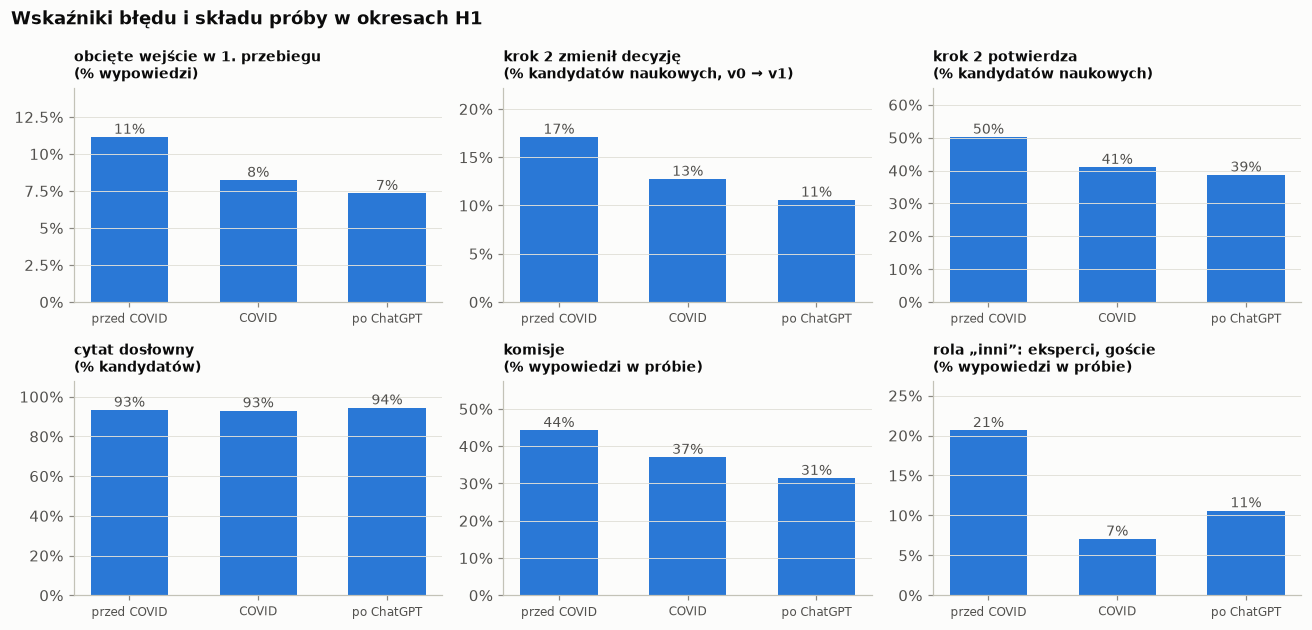

okres,przed COVID,COVID,po ChatGPT
obcięte wejście w 1. przebiegu\n(% wypowiedzi),11.1,8.2,7.3
"krok 2 zmienił decyzję\n(% kandydatów naukowych, v0 → v1)",17.1,12.7,10.6
krok 2 potwierdza\n(% kandydatów naukowych),50.2,41.0,38.7
cytat dosłowny\n(% kandydatów),93.3,93.0,94.4
komisje\n(% wypowiedzi w próbie),44.3,37.1,31.4
"rola „inni”: eksperci, goście\n(% wypowiedzi w próbie)",20.7,7.1,10.6


In [36]:
ind = pd.DataFrame({
    "obcięte wejście w 1. przebiegu\n(% wypowiedzi)": first.groupby("okres")["przepelnienie"].mean(),
    "krok 2 zmienił decyzję\n(% kandydatów naukowych, v0 → v1)": flip.groupby("okres")["zmiana"].mean(),
    "krok 2 potwierdza\n(% kandydatów naukowych)": nauk.groupby("okres")["weryfikacja"].mean(),
    "cytat dosłowny\n(% kandydatów)": cand.groupby("okres")["cytat_doslowny"].mean(),
    "komisje\n(% wypowiedzi w próbie)": df["zrodlo"].eq("komisje").groupby(df["okres"]).mean(),
    "rola „inni”: eksperci, goście\n(% wypowiedzi w próbie)": df["rola"].eq("inni").groupby(df["okres"]).mean(),
}).loc[PERIODS]
fig, axes = plt.subplots(2, 3, figsize=(12, 5.8))
for ax, col in zip(axes.flat, ind.columns):
    v = ind[col]
    ax.bar(range(len(PERIODS)), v, color=ACCENT, width=0.6)
    for i, val in enumerate(v):
        ax.text(i, val, f"{val:.0%}", ha="center", va="bottom", fontsize=9, color=INK2)
    ax.set_xticks(range(len(PERIODS)), [PERIOD_LABEL[p] for p in PERIODS], fontsize=8)
    ax.set_ylim(0, min(max(v.max() * 1.3, 0.05), 1.08)); ax.yaxis.set_major_formatter(PCT)
    ax.set_title(col, fontsize=9, loc="left", pad=6, fontweight="bold")
    ax.grid(axis="x", visible=False)
fig.suptitle("Wskaźniki błędu i składu próby w okresach H1", x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "llm_a_16_bledy_okresy"); plt.show()
ind.mul(100).round(1).rename(index=PERIOD_LABEL).T

* Wskaźniki samego instrumentu różnią się między okresami: obcięte wejście w pierwszym przebiegu 11% / 8% / 7%, zmiana decyzji
  kroku 2 po dodaniu kontekstu 17% / 13% / 11%, odsetek potwierdzeń w kroku 2 50% / 41% / 39%.
* Do tego dochodzą różnice składu: komisje 44% → 37% → 31%, rola „inni” 21% → 7% → 11%.
* Po naprawie przepełnienia pozostałe różnice podnoszą wynik okresu przed COVID. Część spadku po 2020 r. może więc wynikać
  z działania instrumentu i ze składu próby, a nie ze zmiany sposobu wypowiadania się.
* Wnioski: błąd instrumentu trzeba mierzyć osobno w każdym okresie, a estymacja dla H1 musi kontrolować źródło i rolę mówcy
  albo zawęzić populację.

### 9.9 Podsumowanie źródeł błędu

| # | problem | dowód (ten notatnik) | kierunek | różny w okresach? | stan |
|---|---|---|---|---|---|
| 1 | **obcięte wejście**: prompt > 8192 tokenów, instrukcje tracone | 66 wyp. (9%) w 1. przebiegu; twierdzenie w 3% wobec 30% | zaniżało, zwłaszcza długie wystąpienia | **tak**: 11% / 8% / 7% | naprawione: kontekst 16 384, kontrola tokenów, ponowny przebieg |
| 2 | przesunięcie kontekstu pod koniec odpowiedzi | 26 wyp. w 1. przebiegu | mały | 4% / 4% / 3% | naprawione |
| 3 | limit 8 kandydatów | 67 wyp. z pełnym limitem; 15 twierdzeń z pozycji 9–16 | lekko zaniżał | – | naprawione: limit 16 (pełny w 4 wyp.) |
| 4 | krok 2 oceniał parafrazę bez kontekstu | 14% decyzji zmienionych po dodaniu kontekstu | oba kierunki | **tak**: 17% / 13% / 11% zmian | zmienione: krok 2 z kontekstem; jakość nieznana |
| 5 | krok 2 odrzuca część kandydatów | 55% kandydatów „naukowe” odrzuconych; 37% plenarne vs 52% komisje | oba kierunki; może zaniżać twierdzenia sprzeczne z konsensusem | **tak**: potwierdzenia 50% / 41% / 39% | otwarte: ręczna anotacja |
| 6 | granica naukowe / statystyka / prawo | 9.6 | oba kierunki | nieznany | otwarte |
| 7 | etykieta `energia_jadrowa` jako „energetyka” | 31% twierdzeń dotyczy atomu | analiza per temat | tak (CCS w 2023 r.) | otwarte |
| 8 | zmienność między uruchomieniami | zgodność 98%, kappa 0,96 (60 wyp.) | szum | za mała próba, by sprawdzić | zmierzone: mała |
| 9 | przeciekanie przykładów z promptu | 1 cytat skopiowany z przykładu (na 2107 kandydatów) | zawyża | nieznany | otwarte: odrzucać cytaty nieobecne w tekście |
| 10 | populacja = filtr regex | 8% wzmianek o COVID zawiera twierdzenie o COVID; czułość filtra nieznana | mianownik zależny od tematów dnia | **tak**: COVID zwiększa liczbę trafień | otwarte |
| 11 | skład próby: komisje i eksperci | komisje 44% / 37% / 31%, „inni” 21% / 7% / 11% | przesuwa różnice okresów | **tak** | otwarte: warstwy lub zmienne w modelu |
| 12 | krok 1 z dwóch przebiegów | 601 wyp. z kontekstem 8192, 119 z 16 384 | mały (zmiana dotyczy wypowiedzi, które się mieściły) | nie | zaakceptowane (9.5) |
| 13 | mała próba | 60 / rok, przedział dla roku ok. ±12 pp | szum | nie | otwarte |
| 14 | brak danych odniesienia; jeden model i prompt | – | nieznany | nieznany | ręczna anotacja (rozważana) |

Dla H1 najważniejsze są błędy różnicowe (1, 4, 5, 10, 11): mogą same wytworzyć różnicę między okresami albo ją ukryć.

## 10. Dalszy plan

### 10.1 Co naprawiliśmy i co zostaje

Naprawione po pierwszym przebiegu (sekcje 9.1–9.4):
* przepełnienie kontekstu: kontekst 16 384 tokeny, automatyczna kontrola liczby tokenów, ponowny przebieg 119 wypowiedzi;
* limit kandydatów podniesiony z 8 do 16;
* krok 2 ocenia twierdzenie razem z fragmentem wypowiedzi.

Zostaje na później, bo wymagałoby powtórzenia całej próby:
* krótszy prompt bazowy (dziś ok. 4,7 tys. tokenów);
* doprecyzowanie granicy „naukowe / statystyka / prawo” i etykiety `energia_jadrowa` w prompcie (9.6, 4.4);
* zmienność między uruchomieniami (9.5): można ją zmniejszyć, uruchamiając model kilka razy i biorąc wynik większości
  (kosztem czasu), albo uwzględniać ją jako dodatkowe źródło niepewności;
* populacja ograniczona do filtra regex: twierdzenia w wypowiedziach bez trafień słowników są poza pomiarem.

### 10.2 Model

Obecnie używamy Bielika 11B lokalnie: to polski model otwarty, który mieści się na naszej karcie graficznej, działa bez kosztów
i limitów, a wersję modelu mamy pod kontrolą. Wady: ok. 27 s na wypowiedź, kwantyzacja Q4, niepełna powtarzalność (9.5).
Rozważane kierunki (bez rozstrzygania na tym etapie):

* **Bielik na większej losowej próbie.** Do oszacowania odsetków w okresach nie trzeba klasyfikować całego korpusu; wystarczy
  losowa próba z wagami, jak w tym notatniku, tylko większa (10.5).
* **HerBERT jako szybki filtr** (opcja, nie jesteśmy pewni jej sensu). Dostrajalibyśmy go na wynikach Bielika, więc jakości
  nie poprawi: nauczy się błędów Bielika i doda własne, a jego błąd i tak trzeba by zmierzyć na ręcznie oznaczonych danych.
  Daje tylko szybkość: przenosi ocenę Bielika na cały korpus w krótkim czasie. Ma to sens wtedy, gdy potrzebny jest wynik dla
  każdej wypowiedzi (np. szeregi miesięczne albo analiza na poziomie posła), a nie tylko odsetki w okresach.
* **Większy model otwarty** wymagałby więcej pamięci GPU niż mamy. Warto do niego wrócić, jeśli ręczna anotacja pokaże, że Bielik
  myli się za często.

Który wariant jest lepszy, rozstrzygnęłaby dopiero ręczna anotacja (10.4).

### 10.3 Jak mierzymy zjawisko

```
wypowiedzi merytoryczne (populacja)
   │  losowa próba warstwowa (rok; ewentualnie też źródło) z wagami
   │  [opcjonalnie filtr wstępny: słowniki albo HerBERT]
   ▼
etap A (LLM): twierdzenia naukowe (cytat, parafraza, temat, atrybucja)
   ▼
etap B: werdykt względem źródeł opublikowanych przed dniem wypowiedzi (dokumenty instytucji, wyszukiwanie źródeł;
        bez polegania na wiedzy LLM-a)
   ▼
prawda / fałsz / nierozstrzygalne
   ▼
agregacja: twierdzenie → wypowiedź → okres; test z uwzględnieniem błędu klasyfikatora
```

Co z tej eksploracji wynika dla pomiaru:
* **Jednostka.** Twierdzenie, bo prawie połowa wypowiedzi z twierdzeniem ma ich kilka (sekcja 3); wynik dla wypowiedzi
  to agregat.
* **Mianownik.** Udział wypowiedzi z twierdzeniem naukowym sam zmienia się w czasie (sekcja 5). Odsetek twierdzeń fałszywych
  wśród twierdzeń naukowych i odsetek wypowiedzi z twierdzeniem fałszywym wśród wszystkich wypowiedzi mogą więc dać różne
  wnioski; warto liczyć oba.
* **Skład.** Udział komisji i ekspertów zmienia się między okresami (sekcje 1, 5, 6); trzeba go kontrolować (warstwy w losowaniu
  albo zmienne w modelu) albo zawęzić populację.
* **Błąd instrumentu** może różnić się między okresami (sekcja 9), więc trzeba go mierzyć osobno w każdym okresie.
* **Istotność.** Zgodnie z sugestią prowadzącego wyznaczymy ją z uwzględnieniem niepewności klasyfikatora, np. korektą
  Rogana–Gladena z bootstrapem albo metodą prediction-powered inference (Angelopoulos i in., 2023). Obie wymagają ręcznie
  oznaczonej próby.

### 10.4 Ręczna anotacja (rozważana)

Rozważamy ręczne oznaczenie części wypowiedzi, żeby oszacować błąd instrumentu. Pozwoliłoby to:
* zmierzyć precyzję i czułość kroku 1, kroku 2 i całości, osobno w okresach;
* sprawdzić, czy krok 2 nie odrzuca częściej twierdzeń sprzecznych z konsensusem (9.4);
* oszacować, ile twierdzeń gubi filtr regex (anotacja wypowiedzi spoza filtra);
* ocenić atrybucję i wierność parafraz;
* porównać zmienność modelu (9.5) ze zgodnością dwóch anotatorów.

Kilkadziesiąt wypowiedzi pokazałoby rząd wielkości błędu; do korekty istotności potrzeba więcej, rzędu kilkuset.
Anotację trzeba by zrobić przed obejrzeniem wyników modelu, żeby ich nie sugerować.

### 10.5 Wykonalność

In [37]:
sec_first = first.loc[~first["wypowiedz_id"].isin(rerun_ids), "sekundy"].mean()
sec_long = df.loc[df["wypowiedz_id"].isin(rerun_ids), "sekundy"].mean()
share_long = len(rerun_ids) / len(df)
sec = (1 - share_long) * sec_first + share_long * sec_long + df["sekundy_weryfikacji"].mean()
est_claims = R.weighted_total(df, "okres", y="n_twierdzen").loc[PERIODS]
display(pd.Series({
    "szacowany czas Bielika po naprawie [s / wypowiedź]": round(sec, 1),
    f"cały filtr regex ({len(filt):,} wyp.) [h]": round(len(filt) * sec / 3600),
    f"wszystkie merytoryczne ({len(mer):,} wyp.) [h]": round(len(mer) * sec / 3600),
}).to_frame("wartość"))
est_claims.rename(index=PERIOD_LABEL).round().astype(int).to_frame("szac. twierdzenia naukowe w populacji filtra")

,wartość
szacowany czas Bielika po naprawie [s / wypowiedź],26.7
"cały filtr regex (19,417 wyp.) [h]",144.0
"wszystkie merytoryczne (187,665 wyp.) [h]",1392.0


,szac. twierdzenia naukowe w populacji filtra
okres,
przed COVID,3370
COVID,4062
po ChatGPT,2719


In [38]:
z_a, z_b = NormalDist().inv_cdf(0.975), NormalDist().inv_cdf(0.8)


def n_per_group(p0, d):
    p1 = p0 + d
    pb = (p0 + p1) / 2
    return int(np.ceil((z_a * np.sqrt(2 * pb * (1 - pb)) + z_b * np.sqrt(p0 * (1 - p0) + p1 * (1 - p1))) ** 2 / d ** 2))


power = pd.DataFrame({f"wzrost o {d * 100:.0f} pp": [n_per_group(p0, d) for p0 in (0.05, 0.10, 0.20)] for d in (0.03, 0.05, 0.10)},
                     index=pd.Index(["5%", "10%", "20%"], name="odsetek fałszywych przed COVID"))
display(Markdown("**Liczba twierdzeń ocenionych w etapie B potrzebna w każdym okresie** (test dwóch proporcji, α = 0,05, moc 80%, "
                 "bez błędu klasyfikatora i bez skupienia w mówcach)"))
power

**Liczba twierdzeń ocenionych w etapie B potrzebna w każdym okresie** (test dwóch proporcji, α = 0,05, moc 80%, bez błędu klasyfikatora i bez skupienia w mówcach)

,wzrost o 3 pp,wzrost o 5 pp,wzrost o 10 pp
odsetek fałszywych przed COVID,,,
5%,1059,435,141
10%,1774,686,199
20%,2943,1094,294


* Bielik po naprawie potrzebuje średnio ok. 27 s na wypowiedź: cały filtr regex to ok. 144 h pracy GPU, wszystkie wypowiedzi
  merytoryczne ok. 1400 h. Pełny korpus wymaga więc szybkiego filtra albo większej mocy obliczeniowej, a losowa próba kilku
  tysięcy wypowiedzi to kilkadziesiąt godzin.
* W populacji filtra jest szacunkowo 10 tys. twierdzeń naukowych (3,4 / 4,1 / 2,7 tys. w okresach H1), a w oknach 90 dni przed
  wyborami ok. 1,6 tys.
* Tabela mocy (scenariusze, nie założenia): jeśli przed COVID 10% twierdzeń jest fałszywych, wykrycie wzrostu o 5 pp wymaga
  ok. 690 ocenionych twierdzeń w każdym okresie. Przy ok. 50 twierdzeniach na 100 wypowiedzi to ok. 1,4 tys. wypowiedzi na okres,
  razem ok. 4 tys. wypowiedzi i ok. 30 h pracy Bielika. Błąd klasyfikatora i skupienie twierdzeń w mówcach zwiększą tę liczbę.
  Przy mniejszym efekcie (3 pp) potrzeba 1–3 tys. twierdzeń na okres.

## 11. Podsumowanie

**Co wiemy po eksploracji próby LLM**

1. Ok. 25% wypowiedzi z filtra regex zawiera twierdzenie naukowe (w próbie 204 z 720 wypowiedzi, 441 twierdzeń); w populacji
   filtra szacunkowo 4,9 tys. wypowiedzi i 10 tys. twierdzeń.
2. Ponad połowa wypowiedzi z twierdzeniem ma ich więcej niż jedno, więc jednostką etapu B jest twierdzenie, agregowane później
   do wypowiedzi.
3. Wzmianka to nie twierdzenie: tylko 8% wypowiedzi wspominających COVID zawiera twierdzenie naukowe o COVID, a ponad jedna
   trzecia twierdzeń dotyczy tematów spoza słowników. Skala tematów z `01` nie przekłada się na materiał do weryfikacji.
4. Udział wypowiedzi z twierdzeniem spada po 2020 r. (36% → 24% → 21%), ale liczba twierdzeń w populacji jest najwyższa
   w okresie COVID, a część spadku wyjaśniają skład próby (mniej komisji i ekspertów po 2020 r.) i różnice w działaniu
   instrumentu między okresami.
5. Eksperci i goście komisji to 14% wypowiedzi, ale 38% twierdzeń.
6. Instrument: pierwszy przebieg miał cichy błąd przepełnienia kontekstu w 9% wypowiedzi, który zaniżał głównie okres przed COVID;
   po naprawie różnica między okresami wzrosła o 4–6 pp. Wynik jest stabilny między uruchomieniami (kappa 0,96), ale zależy od
   wersji kroku 2 (14% decyzji zmienionych po dodaniu kontekstu).
7. To pomiar etapu A. O sprzeczności wypowiedzi z konsensusem ten notatnik jeszcze nic nie mówi.

**Ograniczenia**

* Brak ręcznie oznaczonych danych odniesienia: precyzja i czułość instrumentu są nieznane i mogą się różnić między okresami.
* Populacja ograniczona do wypowiedzi z trafieniem słowników; twierdzenia poza filtrem są poza pomiarem.
* Krok 1 pochodzi z dwóch przebiegów: 601 wypowiedzi z pierwszego (kontekst 8192, limit 8), 119 z ponownego (16 384, limit 16).
  Dla wypowiedzi, które mieściły się w kontekście i nie zapełniały limitu, zmiana ustawień nie powinna systematycznie zmieniać
  wyniku, a zmienność między uruchomieniami jest mała (9.5).
* 60 wypowiedzi na rok daje szerokie przedziały dla lat, tematów i bloków; wnioski opieramy na porównaniu okresów.
* Jeden model i jeden prompt kroku 1, strojony na 20 wypowiedziach (część przykładów w prompcie pochodzi z nich).
* Parafrazę twierdzenia generuje LLM i może ona przesunąć sens wypowiedzi; cytat źródłowy jest zachowany do kontroli.
* Rok 2026 obejmuje dane do dnia pobrania korpusu; okresy H1 mają różną długość.